In [209]:
import pickle
import behavior.boris_extraction as boris
import spike.spike_analysis.spike_collection as sc
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import sem
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import os
import trodes.read_exported as tr
import h5py


def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))
    


In [210]:
boris_path = r"C:\Users\megha\Documents\Padilla-Coreano\cum_socialmem_ephys\pilot2\boris\only_subjects"

boris_dfs = {}

for file in os.listdir(boris_path):
    csv_path = os.path.join(boris_path, file)
    df = pd.read_csv(csv_path)
    boris_dfs[file] = df

In [211]:
def print_hdf5_info(obj, indent=0):
    """Recursively prints information about datasets and groups in an HDF5 file."""
    if isinstance(obj, h5py.File) or isinstance(obj, h5py.Group):
        for key in obj.keys():
            print(' ' * indent + f"{'/' if indent == 0 else ''}{key}:")
            print_hdf5_info(obj[key], indent + 4)
    elif isinstance(obj, h5py.Dataset):
        print(' ' * indent + f"{'/' if indent == 0 else ''}{obj.name} (Dataset)")
        print(' ' * (indent + 4) + f"Shape: {obj.shape}")
        print(' ' * (indent + 4) + f"Dtype: {obj.dtype}")
        if obj.attrs:
            print(' ' * (indent + 4) + "Attributes:")
            for attr_name, attr_value in obj.attrs.items():
                print(' ' * (indent + 8) + f"{attr_name}: {attr_value}")
    else:
        print(' ' * indent + f"Unknown object: {obj}")

def make_dict(my_list):
    my_dict = {}
    for i in range(len(my_list)):
        my_dict[my_list[i]] = i
    return my_dict

class sleap_vid():
    """
    A class for sleap videos initiated by the filename (.h5 only) and the number of mice 
    you annotated. 

    Attributes:
        name: str, path to an .h5 file 
        mice: number of mice in the experiment, also called tracks 
        locations: np.array, a multidimensional array of dimensions
            (frames, nodes, 2 (x/y coordinates), track_no)
        tracks: list of str, names of tracks assigned during sleap annotation
        nodes: list of str, names of nodes assigned during sleap annotation
        track_dict: dict, keys: str, names of tracks, values: int, dimension of location
            associated with that track
        node_dict: dict, keys: str, names of nodes, values: int, dimension of location 
            associated with that node
                
    Methods:
        smooth_locations: smooths locations with a savtisky-golay filter
        node_velocity: calculates and returns the velocity of a given node 
            for all tracks
        distance_between_mice: calculates and returns distances between tracks
            given a node
        distances_between_nodes: calculates and returns distances between nodes within 
            one skeleton for all tracks
        distances_to_point: calculates and returns distances between a point (x,y coordinates) 
            and a node for each track
        node_angles: calculates and returns the angle between three nodes for each track
        point_angles: calculates and returns the angle between a point and two nodes for
            each track
        orientation: calculates and returns the orientation of the two tracks to each other
        create_events_array: TBD
    """

    def __init__(self, filename):
        """
        Initiates a sleap_vid class instance 
        Args (2)
            filename: str, path to .h5 file 
            track_no: int, number of mice that you annotated for
        
        Returns: 
            a sleap_vid class instance 
        """
        self.name = '_'.join((filename.split('/')[-1].split('_'))[0:4])
        #self.mice = track_no
        self.__get_info__(filename)

    def __get_info__(self, filename):                                                                                                       
      with h5py.File(filename, "r") as f:  
          tracks = [n.decode() for n in f["track_names"][:]]
          locations = f["tracks"][:].T  # (frames, nodes, 2, n_tracks)
          nodes = [n.decode() for n in f["node_names"][:]]     
          point_scores = f['point_scores'][:]                                                                           
  
      #self.locations = fill_missing(locations)                                                                                            
      self.tracks = tracks                 
      self.nodes = nodes  
      self.locations = locations  
      self.point_scores = point_scores                                                                                                             
      self.track_dict = make_dict(tracks)
      self.node_dict = make_dict(nodes)                                                                                                   
                                           


def fill_missing(Y, kind="linear"):
    """Fills missing values independently along each dimension after the first."""

    # Store initial shape.
    initial_shape = Y.shape

    # Flatten after first dim.
    Y = Y.reshape((initial_shape[0], -1))

    # Interpolate along each slice.
    for i in range(Y.shape[-1]):
        y = Y[:, i]

        # Build interpolant.
        x = np.flatnonzero(~np.isnan(y))
        f = interp1d(x, y[x], kind=kind, fill_value=np.nan, bounds_error=False)

        # Fill missing
        xq = np.flatnonzero(np.isnan(y))
        y[xq] = f(xq)
        
        # Fill leading or trailing NaNs with the nearest non-NaN values
        mask = np.isnan(y)
        y[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), y[~mask])

        # Save slice
        Y[:, i] = y

    # Restore to initial shape.
    Y = Y.reshape(initial_shape)

    return Y

def smooth_diff(node_loc, deriv, win=25, poly=3):
    """
    node_loc is a [frames, 2] array
    
    win defines the window to smooth over
    
    poly defines the order of the polynomial
    to fit with
    
    """
    node_vel = np.zeros_like(node_loc)
    for c in range(node_loc.shape[-1]):
        node_vel[:, c] = savgol_filter(node_loc[:, c], win, poly, deriv)
    if deriv != 0:
        node_vel = np.linalg.norm(node_vel,axis=1)
    return node_vel


def smooth_locations(locations, win=25, poly=3):
    """
    Smooths locations using a savitsky-golay filter (fxn from numpy, code from
    sleap.ai) and reassigns self.locations to the smoothed locations

    Args (0 required, 2 total):
        win: int, length of filter window
        poly: int, the order of the polynomial used to fit the samples

    Returns:
        none
    """
    for node in range(locations.shape[1]):
        for track in range(locations.shape[-1]):
            nodeloc = locations[:,node,:,track]
            smoothed_node = smooth_diff(nodeloc, deriv=0, win=win, poly=poly)
            locations[:,node,:,track] = smoothed_node
    return locations
    

def node_velocity(locations, node_idx, win=25, poly=3, normalization_factor=None):
    """
    takes in node and returns the velocity of that node 
    for each mouse

    Args: 
        node: string, name of node
    
    Returns:
        velocities: 2d np.array of floats (d = 2 x #of frames)
            where each element is the velocity for that node
            distances[0] = velocities for mouse2
            distances[1] = velocities for mouse2
    """
    node_loc1 = locations[:, node_idx, :, 0]
    node_loc2 = locations[:, node_idx, :, 1]
    if normalization_factor is not None:
        node_loc1 = node_loc1 * normalization_factor
        node_loc2 = node_loc2 * normalization_factor
    m1_vel = smooth_diff(node_loc1, deriv = 1, win=win, poly=poly)
    m2_vel = smooth_diff(node_loc2, deriv = 1, win=win, poly=poly)
    velocities = np.array([m1_vel,m2_vel])
    return velocities 

def distances_between_mice(locations, node_index, normalization_factor=None):
    """
    takes in node name
    returns a list of distances between the nodes of the two mice

    Args:
        node: string, name of node
    Returns:
        c_list: 1D np.array of floats (d = # of frames)
    """
    
    x1 = locations[:,node_index,0,0]
    y1 = locations[:,node_index,1,0]
    # x , y coordinate of nose for mouse 1
    x2 = locations[:,node_index,0,1]
    y2 =  locations[:,node_index,1,1]
    # x and y coordinate of nose of mouse 2
    # solve for c using pythagroean theory
    distances = np.sqrt(((x1 - x2)**2) + ((y1 - y2)**2))
    if normalization_factor is not None: 
        distances = distances * normalization_factor
        distances = distances.T.flatten()
    return distances

def distances_between_nodes(locations, node_index1, node_index2, normalization_factor = None):
    """
    takes in two nodes and returns the distances between those nodes 
    for each mouse

    Args: 
        node1: string, name of node 1
        node2: string, name of node 2 
    
    Returns:
        distances: 2d np.array of floats (d = 2 x #of frames)
            where each element is the distance between node1 and node2 
            distances[0] = distances for mouse1
            distances[1] = distances for mouse2
    """
    x1,y1 = locations[:, node_index1,0,0], locations[:,node_index1,1,0]
    # x , y coordinate of node 1 for mouse 1
    x2,y2 = locations[:,node_index2,0,0], locations[:,node_index2,1,0]
    # x, y coordiantes of node 2 for mouse 1
    x3, y3 = locations[:,node_index1,0,1], locations[:,node_index1,1,1]
    # x and y coordinate of node 1 of mouse 2
    x4, y4 = locations[:,node_index2,0,1], locations[:,node_index2,1,1]
    # solve for c using pythagroean theory
    c2 = np.sqrt(((x3 -x4)**2)+ ((y3 - y4)**2))
    c1 = np.sqrt(((x1 - x2)**2) + ((y1 - y2)**2))
    if normalization_factor is not None:
        c2 = (c2*normalization_factor).T.flatten()
        c1 = (c1*normalization_factor).T.flatten()
    distances = np.array([c1, c2])
    return distances

def node_angles(locations, node1_index, node2_index, node3_index):
    """
    takes in locations and three nodes, calculates angle between the three points 
    with the second node being the center point
    
    Args:  
        node1: string, name of node 1
        node2: string, name of node 2 
        node3: string, name of node 3

    Returns:
        ang: 2d np. array (d = 2 x # of frames)
            where each element is the angle between 
            node1 and node3 with node2 as center point 
            angles_all_mice[0] = angles for mouse1
            angles_all_mice[1] = angles for mouse2
    """
    ax = locations[:,node1_index, 0, :]
    ay = locations[:,node1_index, 1, :]
    bx = locations[:,node2_index, 0, :]
    by = locations[:,node2_index, 1, :]
    cx = locations[:,node3_index,0,:]
    cy = locations[:,node3_index, 1, :]
    ang = np.arctan2(cy-by, cx-bx) - np.arctan2(ay-by, ax-bx) 
    ang_swapped = np.arctan2(cy-by, cx-bx) - np.arctan2(cy-by, cx-bx) 
    ang = np.maximum(ang, ang_swapped)
    return ang.T

def orientation(locations, nose_node, head_node, other_node):
    """
    Takes in locations and nose and head node index to calculate the angle of orientation from one mouse
    facing whatever other_node is chosen
    between mice where two mice facing each other results in pi
    theta = 0 means they are not facing each other 
    """
   
    ax = locations[:, nose_node, 0, 0]
    ay = locations[:, nose_node, 1, 0]
    bx = locations[:,head_node, 0, 0]
    by = locations[:,head_node, 1, 0]
    cx = locations[:, other_node, 0, 1]
    cy = locations[:,other_node, 1, 1]
    ang_m1 = np.arctan2(cy-by, cx-bx) - np.arctan2(ay-by, ax-bx) 
    ang_m1_swapped = np.arctan2(ay-by, ax-bx) - np.arctan2(cy-by, cx-bx)
    ax = locations[:, nose_node, 0, 1]
    ay = locations[:, nose_node, 1, 1]
    bx = locations[:,head_node, 0, 1]
    by = locations[:,head_node, 1, 1]
    cx = locations[:, other_node, 0, 0]
    cy = locations[:,other_node, 1, 0]
    ang_m2 = np.arctan2(cy-by, cx-bx) - np.arctan2(ay-by, ax-bx) 
    ang_m2_swapped = np.arctan2(ay-by, ax-bx) - np.arctan2(cy-by, cx-bx) 
    ang_m1 = np.maximum(ang_m1,ang_m1_swapped)
    ang_m2 = np.maximum(ang_m2,ang_m2_swapped)
    return np.array([ang_m1, ang_m2])

def compute_moving_angle(locations, node_idx):
    """
    Compute velocity and moving angle for each point in a trajectory.
    
    Parameters:
    - trajectory: np.array of shape (N, 2), where N is the number of frames, and 2 represents (x, y).

    Returns:
    - velocity: np.array of shape (N,) containing velocity magnitudes.
    - moving_angle: np.array of shape (N,) containing movement direction angles in degrees.
    """
    moving_angle1 = np.zeros(locations.shape[0])
    moving_angle2 = np.zeros(locations.shape[0])
    trajectories1 = locations[:, node_idx, :, 0]
    trajectories2 = locations[:, node_idx, :, 1]
    # Compute velocity as the difference between the next and previous points
    diff1_vectors = trajectories1[1:] - trajectories1[:-1]
    diff2_vectors = trajectories2[1:] - trajectories2[:-1]

    # Compute moving angle using arctan2 (y component first, then x)
    moving_angle1[:-1] = np.degrees(np.arctan2(diff1_vectors[:, 1], diff1_vectors[:, 0]))
    moving_angle2[:-1] = np.degrees(np.arctan2(diff2_vectors[:, 1], diff2_vectors[:, 0]))

    moving_angle = np.stack([moving_angle1, moving_angle2])

    return moving_angle   
                                                                            
def get_ins_outs(boris_df, fps):       
    if len(boris_df[boris_df['Behavior'] == 'mice back in']["Start (s)"]) == 6:
        if 'Image index start' not in boris_df.columns:
            ins_times = np.array(boris_df[boris_df['Behavior'] == 'mice back in']["Start (s)"])[[0,2,4]]
            outs_times = np.array(boris_df[boris_df['Behavior'] == 'mice taken out']["Start (s)"])[[0,2]]
            ins_frames = np.round(ins_times * fps).astype(int)
            outs_frames = np.round(outs_times * fps).astype(int)
        else:
            ins_frames = np.array(boris_df[boris_df['Behavior'] == 'mice back in']["Image index start"])[[0,2,4]]
            outs_frames= np.array(boris_df[boris_df['Behavior'] == 'mice taken out']["Image index start"])[[0,2]]
    else:
        if 'Image index start' not in boris_df.columns:
            ins_times = np.array(boris_df[boris_df['Behavior'] == 'mice back in']["Start (s)"])
            outs_times = np.array(boris_df[boris_df['Behavior'] == 'mice taken out']["Start (s)"])
            ins_frames = np.round(ins_times * fps).astype(int)
            outs_frames = np.round(outs_times * fps).astype(int)
            
        else:
            ins_frames = np.array(boris_df[boris_df['Behavior'] == 'mice back in']["Image index start"])
            outs_frames = np.array(boris_df[boris_df['Behavior'] == 'mice taken out']["Image index start"])
 
    return ins_frames, outs_frames
 




In [212]:
sleap_data = r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\SLEAP\only_subjects_mp4s\final_predictions\id_corrected"
sleap_objs = {}

for file in os.listdir(sleap_data):
    if file.endswith("h5"):
        print(file)
        rec_name = "_".join(file.split("_")[0:4])
        print(rec_name)
        path = os.path.join(sleap_data, file)
        sleap_obj = sleap_vid(path)
        sleap_objs[rec_name] = sleap_obj

11_12_23_24.1_dark_IDcorrected.h5
11_12_23_24.1
11_12_23_24.2_dark_IDcorrected.h5
11_12_23_24.2
11_13_21_22.1_darkIDcorrected.h5
11_13_21_22.1
11_13_21_22.2_predictions_IDcorrected.h5
11_13_21_22.2
21_22_41_44.1_dark_IDcorrected.h5
21_22_41_44.1
21_22_41_44.2_predictions_IDcorrected.h5
21_22_41_44.2
23_24_31_32.1_dark_IDcorrected.h5
23_24_31_32.1
23_24_31_32.2_predictions_IDcorrected.h5
23_24_31_32.2


In [213]:
pairs = []
for rec_pairs in combinations(boris_dfs.keys(), 2):
    rec1 = rec_pairs[0].split('.')[0]
    rec2 = rec_pairs[1].split('.')[0]
    if rec1 == rec2:
        pairs.append(rec_pairs)
pairs

[('11_12_23_24.1.csv', '11_12_23_24.2.csv'),
 ('11_13_21_22.1.csv', '11_13_21_22.2.csv'),
 ('21_22_41_44.1.csv', '21_22_41_44.2.csv'),
 ('23_24_31_32.1.csv', '23_24_31_32.2.csv')]

In [214]:
boris_dfs['23_24_31_32.2.csv']['Behavior'].unique()

array(['mice back in', 'facial sniffing', 'anogenital sniffing',
       'fighting', 'mice taken out', 'anogential sniffing',
       'allogrooming'], dtype=object)

In [215]:
timestamps_dir = (r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Only_Subjects (phase 5)\videoTimeStamps")
timestamps_dict = {}
for root, dirs, files in os.walk(timestamps_dir):
    for file in files:
        if file.endswith('.videoTimeStamps'):
            file_path = os.path.join(root, file)
            timestamp_array = tr.readCameraModuleTimeStamps(file_path)
            rec_name = file.replace('.videoTimeStamps','')
            timestamps_dict[rec_name] = timestamp_array

print(timestamps_dict.keys())

dict_keys(['11_12_23_24.1', '11_12_23_24.2', '11_13_21_22.1', '11_13_21_22.2', '21_22_41_44.1', '21_22_41_44.2', '23_24_31_32.1', '23_24_31_32.2'])


In [216]:
for rec, array in timestamps_dict.items():
    print(rec, array[0])

11_12_23_24.1 78.57875
11_12_23_24.2 78.648
11_13_21_22.1 177.29105
11_13_21_22.2 177.32195
21_22_41_44.1 265.18605
21_22_41_44.2 265.25535
23_24_31_32.1 136.4388
23_24_31_32.2 136.5081


11_12_23_24.1.csv epoch: 0.00min to 10.14min (9126 frames)
11_12_23_24.1.csv epoch: 10.14min to 20.10min (8965 frames)
11_12_23_24.1.csv epoch: 20.20min to 30.08min (8895 frames)
11_12_23_24.1.csv epoch: 30.21min to 40.04min (8848 frames)
11_12_23_24.2.csv epoch: 0.00min to 10.05min (9045 frames)
11_12_23_24.2.csv epoch: 10.05min to 20.10min (9046 frames)
11_12_23_24.2.csv epoch: 20.22min to 30.07min (8867 frames)
11_12_23_24.2.csv epoch: 30.22min to 40.04min (8839 frames)
11_13_21_22.1.csv epoch: 0.00min to 10.18min (9160 frames)
11_13_21_22.1.csv epoch: 10.18min to 20.48min (9268 frames)
11_13_21_22.1.csv epoch: 20.52min to 31.10min (9522 frames)
11_13_21_22.1.csv epoch: 31.16min to 41.72min (9501 frames)
11_13_21_22.2.csv epoch: 0.00min to 10.04min (9039 frames)
11_13_21_22.2.csv epoch: 10.04min to 20.38min (9301 frames)
11_13_21_22.2.csv epoch: 20.59min to 30.98min (9354 frames)
11_13_21_22.2.csv epoch: 31.25min to 41.72min (9421 frames)
21_22_41_44.1.csv epoch: 0.00min to 10.23min

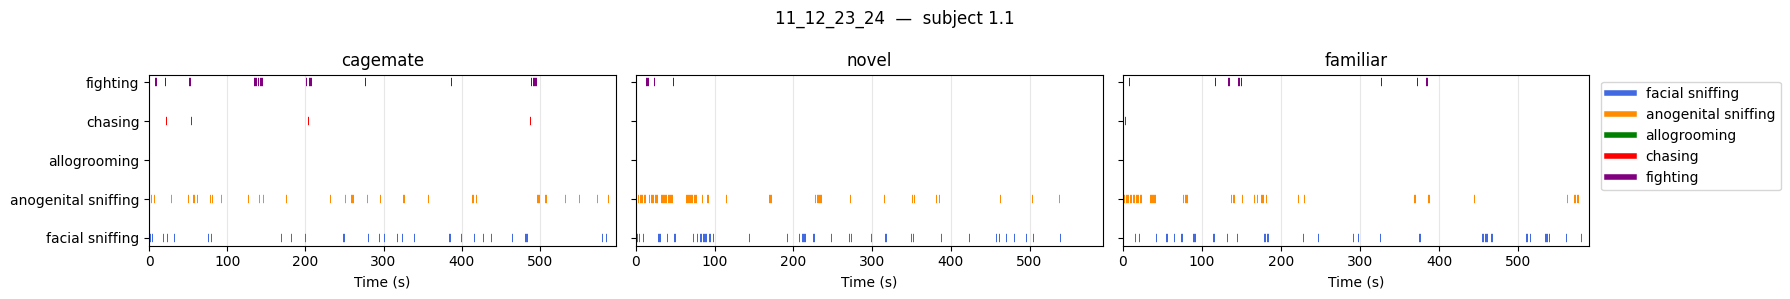

11_12_23_24 1.2: ['cagemate', 'novel', 'familiar']
11_12_23_24 1.2 cagemate: fps=15, len=8965
unique values: [0 1 2]
nonzero count: 1232
11_12_23_24 1.2 novel: fps=15, len=8867
unique values: [0 1 2]
nonzero count: 734
11_12_23_24 1.2 familiar: fps=15, len=8839
unique values: [0 1 2]
nonzero count: 489


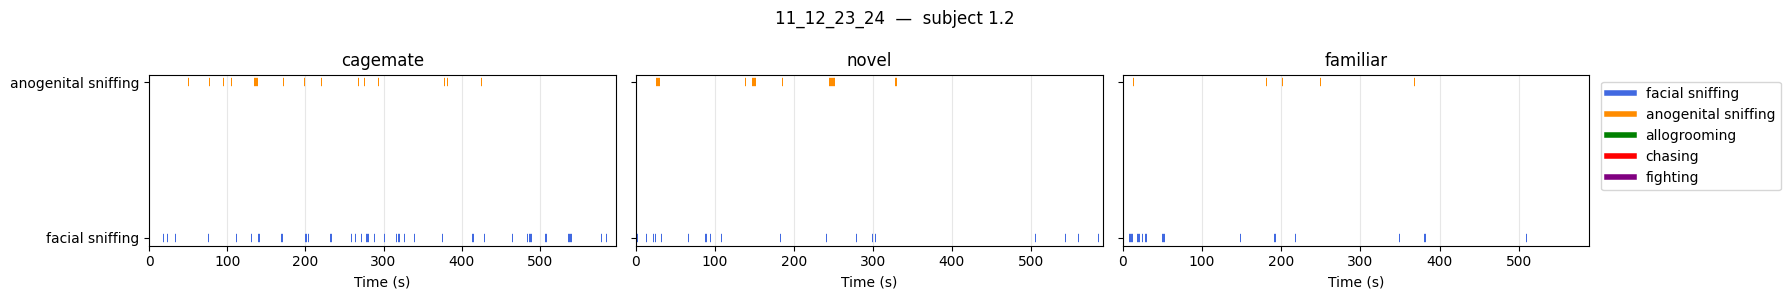

11_12_23_24 2.3: ['familiar', 'cagemate', 'novel']
11_12_23_24 2.3 cagemate: fps=15, len=9046
unique values: [0 1 2]
nonzero count: 239
11_12_23_24 2.3 novel: fps=15, len=8867
unique values: [0 1 2]
nonzero count: 670
11_12_23_24 2.3 familiar: fps=15, len=8848
unique values: [0 1 2]
nonzero count: 1614


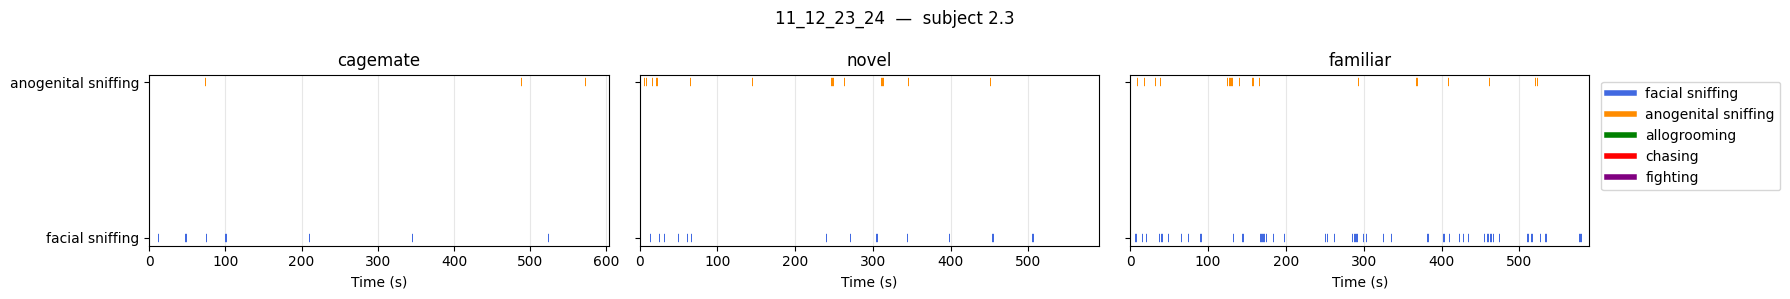

11_12_23_24 2.4: ['novel', 'cagemate', 'familiar']
11_12_23_24 2.4 cagemate: fps=15, len=9046
unique values: [0 1 2]
nonzero count: 135
11_12_23_24 2.4 novel: fps=15, len=8895
unique values: [0 1 2]
nonzero count: 1265
11_12_23_24 2.4 familiar: fps=15, len=8839
unique values: [0 1 2]
nonzero count: 485


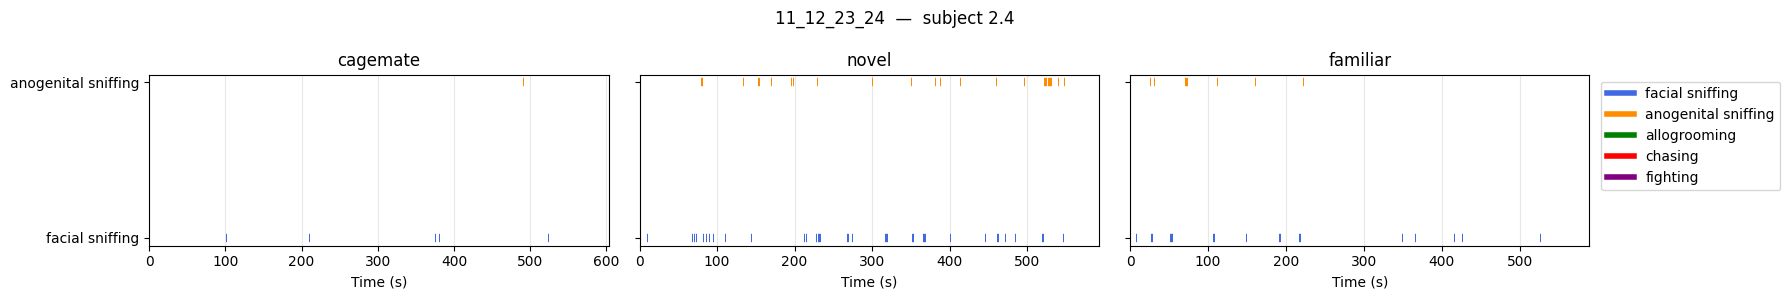

11_13_21_22 1.1: ['cagemate', 'familiar', 'novel']
11_13_21_22 1.1 cagemate: fps=15, len=9522
unique values: [0 1 2 5]
nonzero count: 326
11_13_21_22 1.1 novel: fps=15, len=9301
unique values: [0 1 2 5]
nonzero count: 748
11_13_21_22 1.1 familiar: fps=15, len=9501
unique values: [0 1 2 4 5]
nonzero count: 783


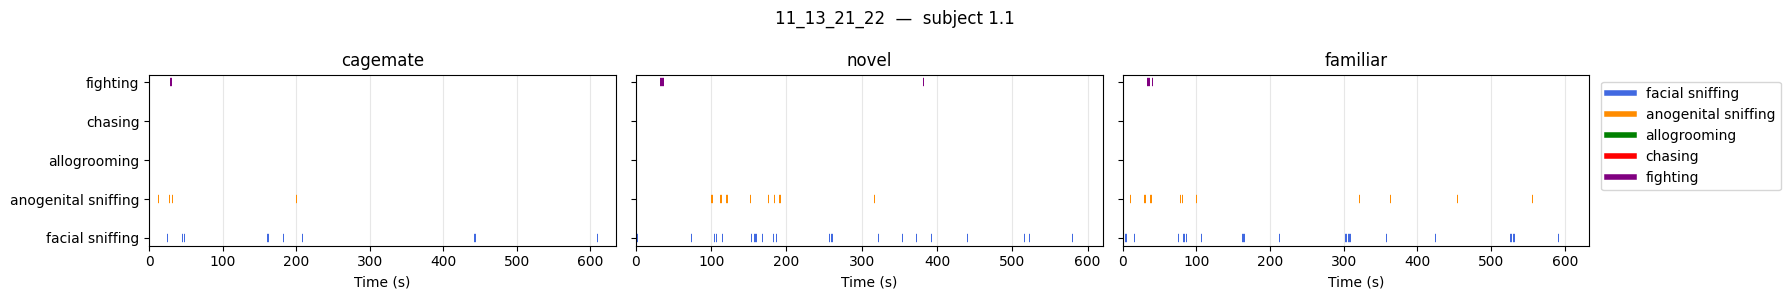

11_13_21_22 1.3: ['novel', 'cagemate', 'familiar']
11_13_21_22 1.3 cagemate: fps=15, len=9522
unique values: [0 1 2]
nonzero count: 382
11_13_21_22 1.3 novel: fps=15, len=9268
unique values: [0 1 2]
nonzero count: 837
11_13_21_22 1.3 familiar: fps=15, len=9421
unique values: [0 1 2]
nonzero count: 421


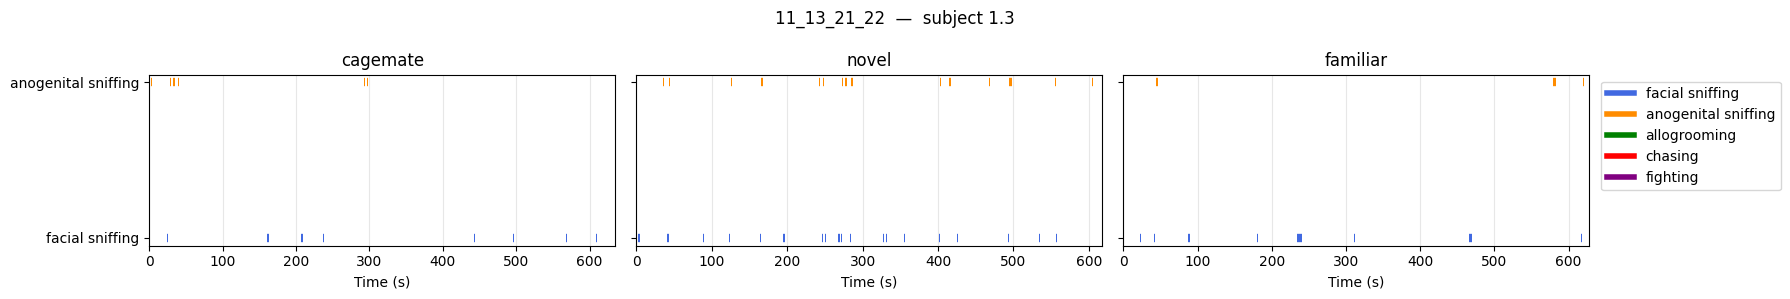

11_13_21_22 2.1: ['novel', 'familiar', 'cagemate']
11_13_21_22 2.1 cagemate: fps=15, len=9354
unique values: [0 1 2]
nonzero count: 513
11_13_21_22 2.1 novel: fps=15, len=9268
unique values: [0 1 2]
nonzero count: 933
11_13_21_22 2.1 familiar: fps=15, len=9501
unique values: [0 1 2]
nonzero count: 175


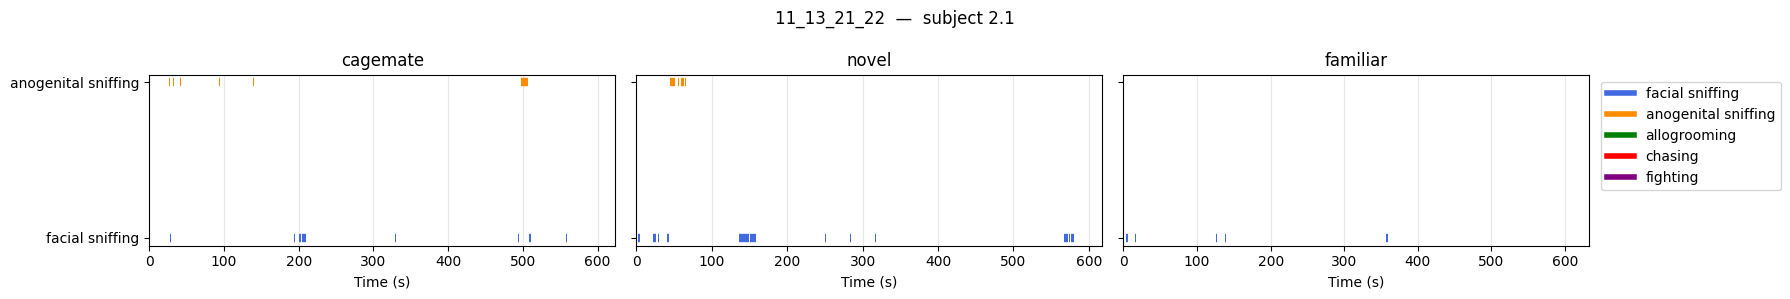

11_13_21_22 2.2: ['novel', 'cagemate', 'familiar']
11_13_21_22 2.2 cagemate: fps=15, len=9354
unique values: [0 1 2]
nonzero count: 180
11_13_21_22 2.2 novel: fps=15, len=9301
unique values: [0 1 2]
nonzero count: 490
11_13_21_22 2.2 familiar: fps=15, len=9421
unique values: [0 1 2 4 5]
nonzero count: 845


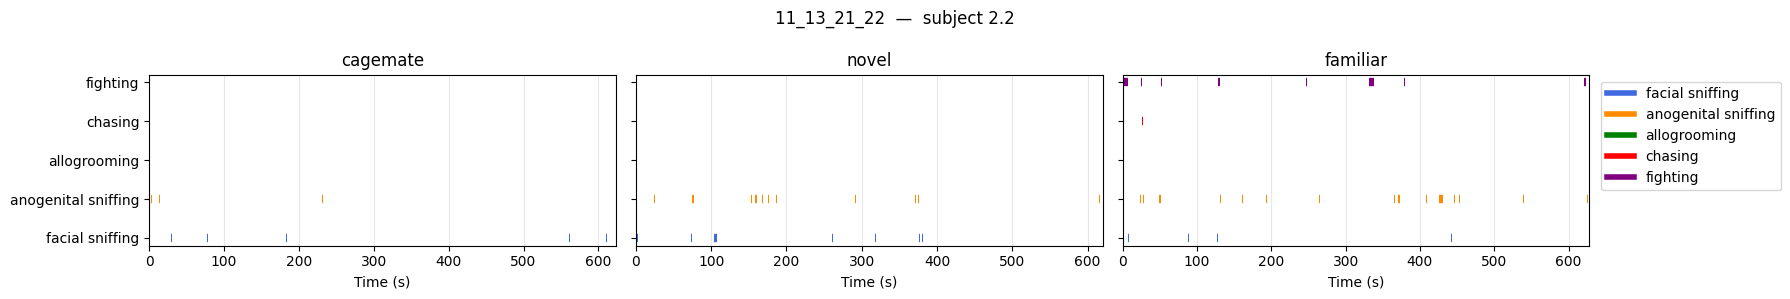

21_22_41_44 2.1: ['familiar', 'cagemate', 'novel']
21_22_41_44 2.1 cagemate: fps=15, len=9098
unique values: [0 1 2]
nonzero count: 660
21_22_41_44 2.1 novel: fps=15, len=9443
unique values: [0 1 2]
nonzero count: 527
21_22_41_44 2.1 familiar: fps=15, len=9329
unique values: [0 1 2 5]
nonzero count: 739


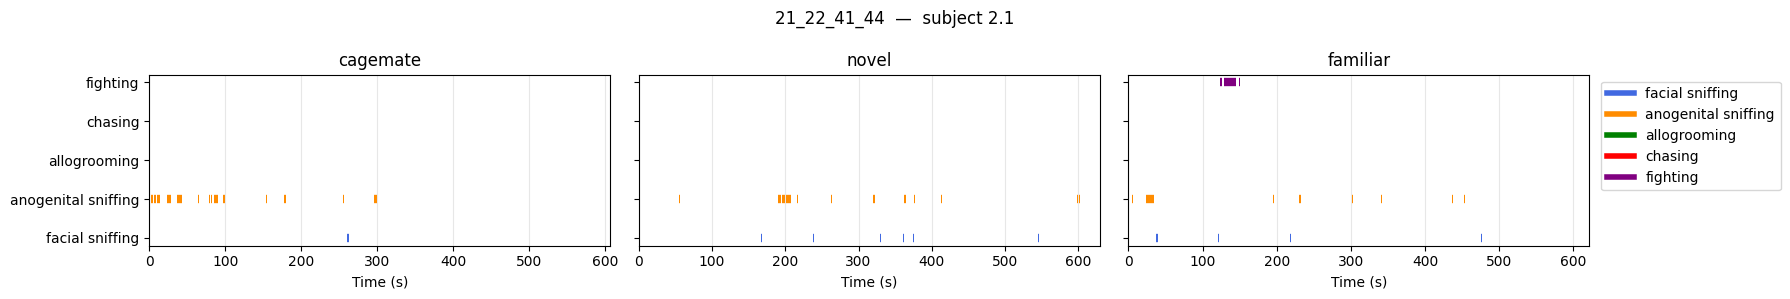

21_22_41_44 2.2: ['cagemate', 'novel', 'familiar']
21_22_41_44 2.2 cagemate: fps=15, len=9098
unique values: [0 1 2]
nonzero count: 48
21_22_41_44 2.2 novel: fps=15, len=9384
unique values: [0 1 2 5]
nonzero count: 321
21_22_41_44 2.2 familiar: fps=15, len=9361
unique values: [0 1 2 5]
nonzero count: 258


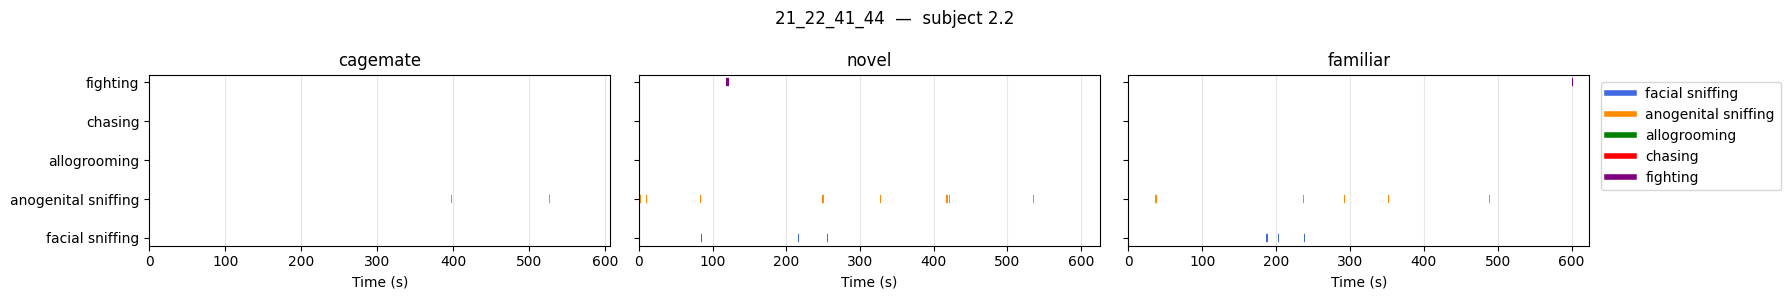

21_22_41_44 4.1: ['familiar', 'novel', 'cagemate']
21_22_41_44 4.1 cagemate: fps=15, len=9145
unique values: [0 1 2 5]
nonzero count: 495
21_22_41_44 4.1 novel: fps=15, len=9384
unique values: [0 1 2]
nonzero count: 426
21_22_41_44 4.1 familiar: fps=15, len=9329
unique values: [0 1 2]
nonzero count: 438


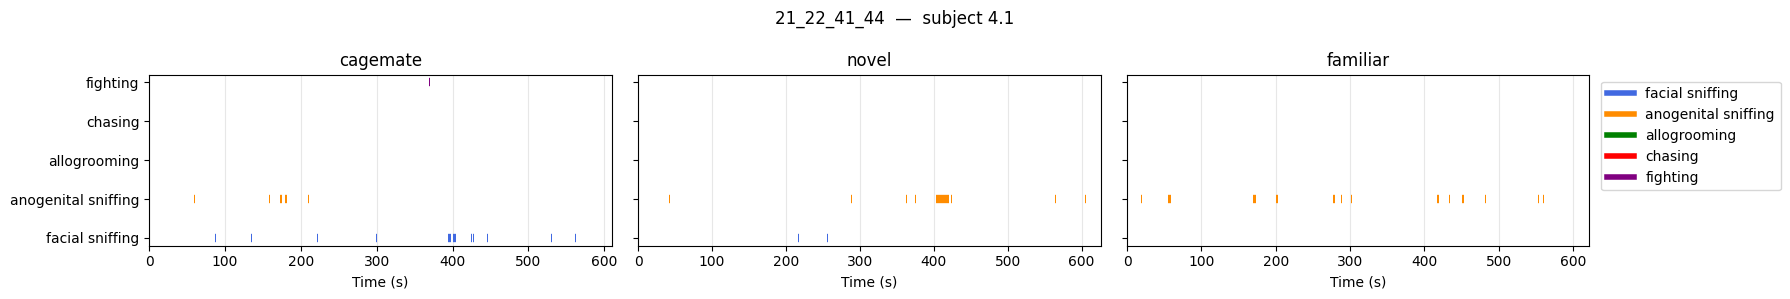

21_22_41_44 4.4: ['familiar', 'cagemate', 'novel']
21_22_41_44 4.4 cagemate: fps=15, len=9145
unique values: [0 1 2 5]
nonzero count: 520
21_22_41_44 4.4 novel: fps=15, len=9443
unique values: [0 1 2]
nonzero count: 737
21_22_41_44 4.4 familiar: fps=15, len=9361
unique values: [0 1 2 5]
nonzero count: 676


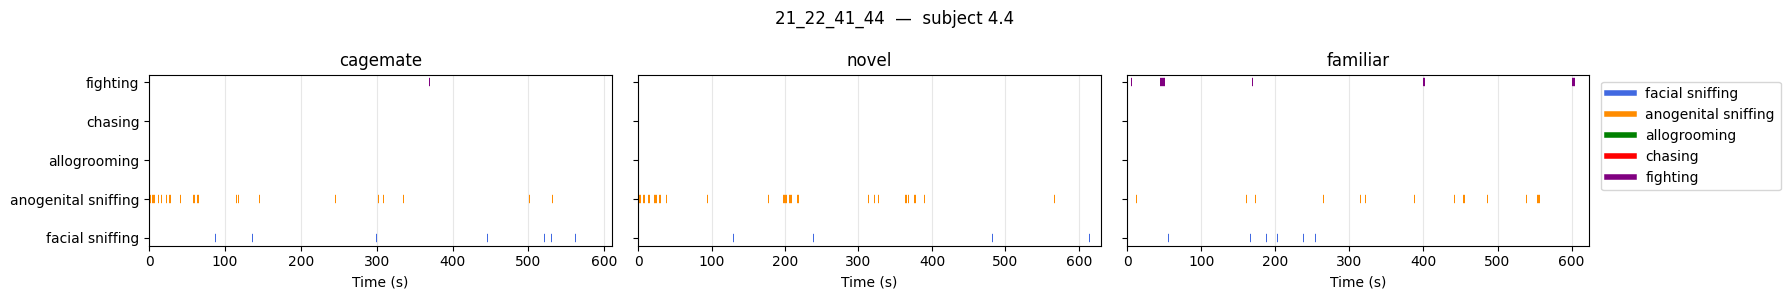

23_24_31_32 2.3: ['novel', 'familiar', 'cagemate']
23_24_31_32 2.3 cagemate: fps=15, len=8768
unique values: [0 1 2]
nonzero count: 474
23_24_31_32 2.3 novel: fps=15, len=9408
unique values: [0 1 2]
nonzero count: 1853
23_24_31_32 2.3 familiar: fps=15, len=8434
unique values: [0 1 2]
nonzero count: 2011


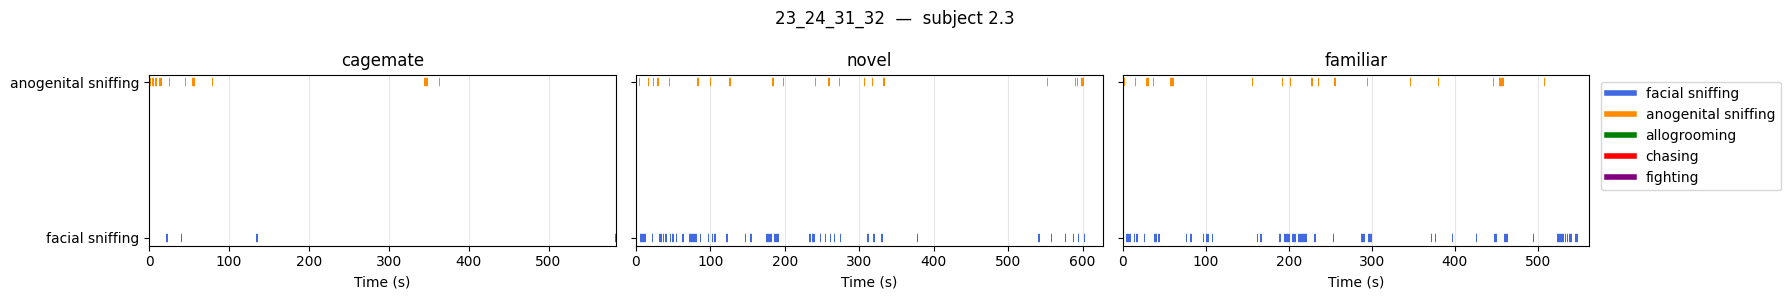

23_24_31_32 2.4: ['cagemate', 'novel', 'familiar']
23_24_31_32 2.4 cagemate: fps=15, len=8768
unique values: [0 1 2]
nonzero count: 405
23_24_31_32 2.4 novel: fps=28, len=9390
unique values: [0 1 2 5]
nonzero count: 2782
23_24_31_32 2.4 familiar: fps=28, len=8582
unique values: [0 1 2 3]
nonzero count: 1074


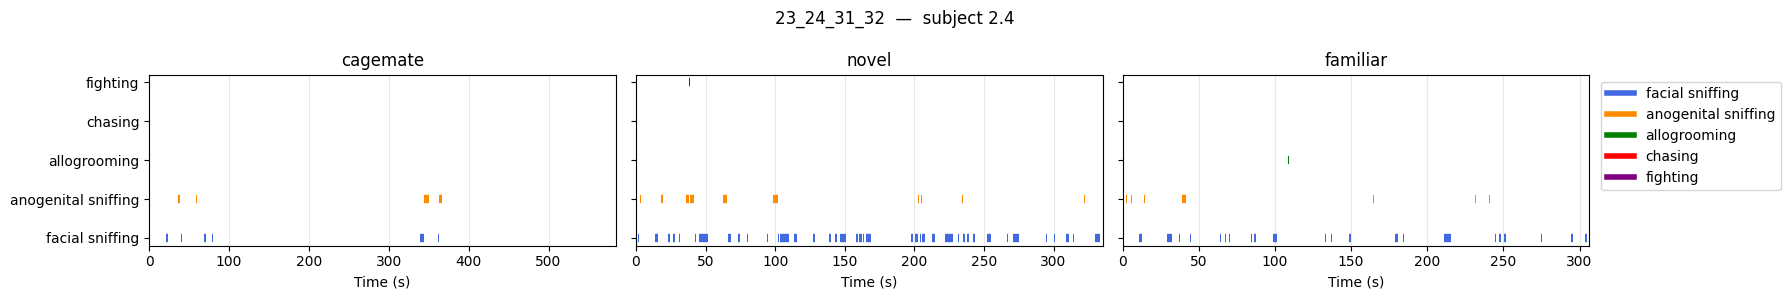

23_24_31_32 3.1: ['familiar', 'novel', 'cagemate']
23_24_31_32 3.1 cagemate: fps=28, len=8839
unique values: [0 1 2]
nonzero count: 2424
23_24_31_32 3.1 novel: fps=28, len=9390
unique values: [0 1 2]
nonzero count: 4544
23_24_31_32 3.1 familiar: fps=15, len=8434
unique values: [0 1 2]
nonzero count: 4016


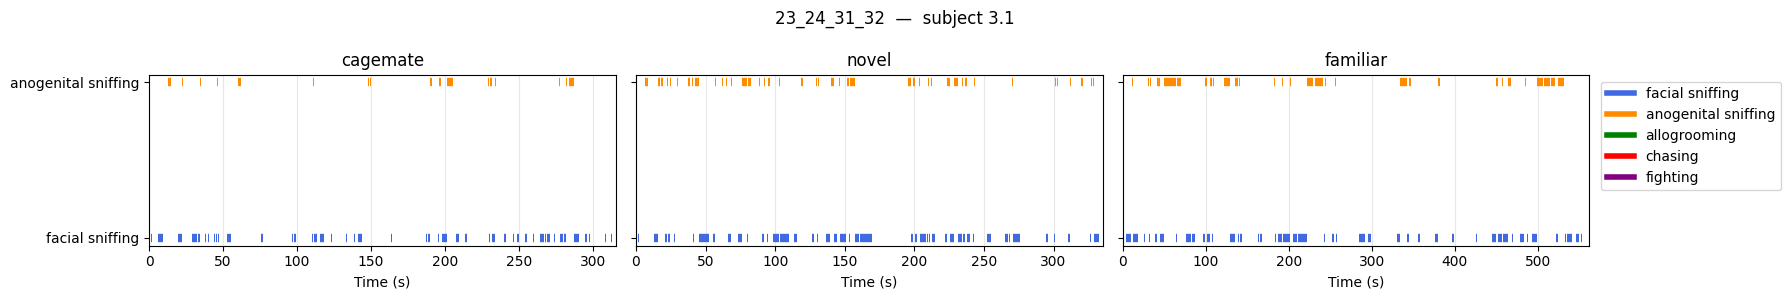

23_24_31_32 3.2: ['novel', 'familiar', 'cagemate']
23_24_31_32 3.2 cagemate: fps=28, len=8839
unique values: [0 1 2]
nonzero count: 1904
23_24_31_32 3.2 novel: fps=15, len=9408
unique values: [0 1 2]
nonzero count: 1633
23_24_31_32 3.2 familiar: fps=28, len=8582
unique values: [0 1 2]
nonzero count: 1205


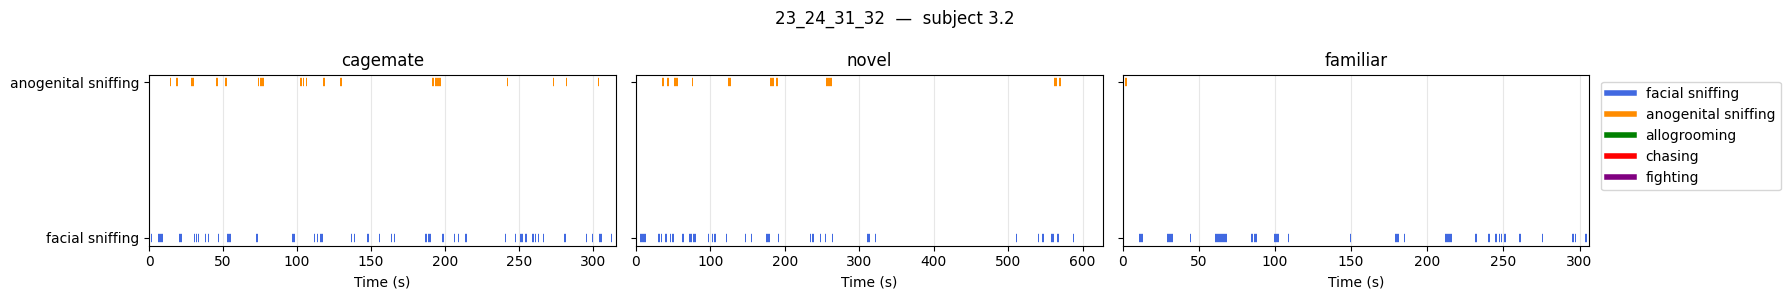

In [217]:
                                                                                                                                                                                           
#create dictionaries that go
# label_array[subject][agent] = boris_data (array of len(total_frames) with behavior labels (integers 0-5) for each frame)
# sleap_label_array[subject][agent] = sleap_data (array of len(total_frames) with x/y coordinates for each node for each frame)

behavior_key = {'facial sniffing': 1,                                                                                                                                                                                                                                   
                  'anogenital sniffing': 2,                                                                                                                                                                                                                               
                  'allogrooming': 3,                                                                                                                                                                                                                                      
                  'chasing': 4,
                  'fighting': 5,                                                                                                                                                                                                                                          
                  'none': 0}                                                                                                                                                                                                                                            

order_dict = {'11_12_23_24': {'cagemate': 1, 'novel': 2, 'familiar': 3},                                                                                                                                                                                                
            '11_13_21_22': {'novel': 1, 'cagemate': 2, 'familiar': 3},
            '21_22_41_44': {'familiar': 1, 'cagemate': 2, 'novel': 3},                                                                                                                                                                                                
            '23_24_31_32': {'novel': 1, 'familiar': 2, 'cagemate': 3}}                                                                                                                                                                                                

label_array = {}                                                                                                                                                                                                                                                              
ins = {}                                                                                                                                                                                                                                                              
outs = {}
frames = {}                                                                                                                                                                                                                                                                 
for rec_pair in pairs:
    common = rec_pair[0].split('.')[0]                                                                                                                                                                                                                                  
    subjects_key = [str(int(common.split('_')[i]) / 10) for i in range(4)]                                                                                                                                                                                            
    label_array[common] = {sk: {} for sk in subjects_key}  
    order = order_dict[common]
                                                                                                                                                                                                                                                                      
    for rec in rec_pair:
        
        rec_name = rec.replace('.csv', '')
        
        for sleap_name, sleap_obj in sleap_objs.items():
            if sleap_name == rec_name:
                current_sleap = sleap_obj 
        example_df = boris_dfs[rec].copy()
        example_df['Subject'] = example_df['Subject'].astype(str)
                                                                                                                                                                                                                                                                        
        for col in example_df.columns:
            if 'FPS' in col:                                                                                                                                                                                                                                              
                fps_col = col
                break
                                                                                                                                                                                                                                                
        fps = int(example_df[fps_col].unique()[0])    
       
        ins[rec], outs[rec] = get_ins_outs(example_df, fps)
        total_frames = current_sleap.locations.shape[0]
        # print(example_df.columns, rec, fps)
        # print('back in times:', example_df[example_df['Behavior'] == 'mice back in']['Start (s)'].values)
        # print('taken out times:', example_df[example_df['Behavior'] == 'mice taken out']['Start (s)'].values)
        if 'Image index start' not in example_df.columns:   
                                                                                                                                                                                                                     
            example_df['Image index start'] = np.round(example_df['Start (s)'] * fps).astype(int)                                                                                                                                                                     
            example_df['Image index stop'] = np.round(example_df['Stop (s)'] * fps).astype(int)
        epochs = [                                                                                                                                                                                                                                                      
            (0, ins[rec][0]),             # baseline                                                                                                                                                                                                                  
            (ins[rec][0], outs[rec][0]),  # first epoch                                                                                                                                                                                                                 
            (ins[rec][1], outs[rec][1]),  # second epoch
            (ins[rec][2], total_frames),  # third epoch                                                                                                                                                                                                                 
        ]    
        for epoch in epochs:
            print(f'{rec} epoch: {epoch[0]/fps/60:.2f}min to {epoch[1]/fps/60:.2f}min ({epoch[1]-epoch[0]} frames)')                                                                                                                                                                                                                                                           
        for s_key in subjects_key:
            sub_df = example_df[                                                                                                                                                                                                                                        
                (example_df['Subject'] == s_key) &                                                                                                                                                                                                                    
                (example_df['Behavior'].isin(behavior_key))
            ].copy()                                                                                                                                                                                                                                                    
         
            sub_df['Image index stop'] = sub_df['Image index stop'].fillna(                                                                                                                                                                                             
                sub_df['Image index start'].shift(-1) - 1                                                                                                                                                                                                             
            )
                                                                                                                                                                                                                                                                        
            if sub_df.empty:
                continue                                                                                                                                                                                                                                                
            frames[rec_name] = {agent: [] for agent in order.keys()}                                                                                                                                                                                                                                                       
            for agent, epoch_idx in order.items():
                
                epoch_start, epoch_end = epochs[epoch_idx]
                epoch_df = sub_df[
                    (sub_df['Image index start'] >= epoch_start) &
                    (sub_df['Image index start'] < epoch_end)                                                                                                                                                                                                           
                ]
                # if s_key == '3.2' and agent == 'familiar':
                #     print('epoch start', epoch_start/fps, epoch_end/fps)
                #     print('frames per second', fps)
                #     print(epoch_df)
                #     print('sub_df in time range (seconds):')
                #     print(sub_df[(sub_df['Start (s)'] >= 665) & (sub_df['Start (s)'] < 972)][['Subject', 'Behavior', 'Start (s)', 'Image index start']])
                #     print(example_df[example_df['Subject'] == '3.2'][['Behavior type', 'Start (s)', 'Stop (s)']].head(20))

              
                frames[rec_name][agent].append([epoch_start, epoch_end])                                                                                                                                                                                                                             
                if epoch_df.empty:                                                                                                                                                                                                                                    
                    continue

                epoch_len = epoch_end - epoch_start
                behavior_array = np.zeros(epoch_len, dtype=int)
                for _, row in epoch_df.iterrows():                                                                                                                                                                                                                      
                    start_idx = int(row['Image index start']) - epoch_start
                    stop_idx = min(int(row['Image index stop']) - epoch_start, epoch_len)                                                                                                                                                                               
                    behavior_array[start_idx:stop_idx] = behavior_key[row['Behavior']]                                                                                                                                                                                  

                if np.any(behavior_array != 0):                                                                                                                                                                                                                         
                 
                    label_array[common][s_key][agent] = {
                                                    'behavior': behavior_array,
                                                    'fps': fps,
                                                    'rec': rec_name,
                                                    'epoch': [epoch_start, epoch_end]
                                                }
                    #print(f'stored {common} {s_key} {agent} from {rec} with {len(behavior_array)} frames at {fps}fps')

            
                    
                    

                       
                    
                    
behavior_colors = {
      'facial sniffing': 'royalblue',
      'anogenital sniffing': 'darkorange',
      'allogrooming': 'green',
      'chasing': 'red',
      'fighting': 'purple',
  }
inv_behavior_key = {v: k for k, v in behavior_key.items() if k != 'none'}

def plot_ethogram(label_array, behavior_key, behavior_colors):
    inv_behavior_key = {v: k for k, v in behavior_key.items() if k != 'none'}
    agents = ['cagemate', 'novel', 'familiar']

    for common, subjects in label_array.items():
        for s_key, agent_arrays in subjects.items():
            print(f'{common} {s_key}: {list(agent_arrays.keys())}')
            if not agent_arrays:
                continue

            fig, axes = plt.subplots(1, 3, figsize=(18, 3), sharey=True)
            fig.suptitle(f'{common}  —  subject {s_key}')

            for ax, agent in zip(axes, agents):
                ax.set_title(agent)
                ax.set_xlabel('Time (s)')
                ax.set_yticks(list(inv_behavior_key.keys()))
                ax.set_yticklabels(list(inv_behavior_key.values()))
                ax.grid(True, axis='x', alpha=0.3)

                if agent not in agent_arrays:
                    continue
                print(f'{common} {s_key} {agent}: fps={agent_arrays[agent]["fps"]}, len={len(agent_arrays[agent]["behavior"])}')


                behavior_array = agent_arrays[agent]['behavior']
                fps = agent_arrays[agent]['fps']
                print(f'unique values: {np.unique(behavior_array)}')
                
                print(f'nonzero count: {np.sum(behavior_array != 0)}')

                for behavior_val, behavior_name in inv_behavior_key.items():
                    is_beh = (behavior_array == behavior_val).astype(int)
                    changes = np.diff(is_beh, prepend=0, append=0)
                    starts = np.where(changes == 1)[0] / fps
                    ends = np.where(changes == -1)[0] / fps
                    for s, e in zip(starts, ends):
                        ax.plot([s, e], [behavior_val, behavior_val],
                                color=behavior_colors[behavior_name], linewidth=6, solid_capstyle='butt')
                ax.set_xlim(0, len(behavior_array) / fps)

            legend_handles = [plt.Line2D([0], [0], color=c, lw=4, label=b)
                              for b, c in behavior_colors.items()]
            axes[-1].legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')

            plt.tight_layout()
            plt.show()
                                                                                                                                                                                                                                                                          
plot_ethogram(label_array, behavior_key, behavior_colors)  
                       

In [218]:
from importlib import reload
from collections import defaultdict
reload(boris)
first_timestamp_dict = unpickle_this("pilot2/only_subjects/first_timestamps_only_subjects")
bouts = {}
sleap = {}
ins_outs = {}
for rec_pair in pairs:
    common = rec_pair[0].split('.')[0]
    subjects = []
    for i in range(4):
        subjects.append(str(int(common.split('_')[i])/10))
    bouts[common] = {str(subject): [] for subject in subjects}
    sleap[common] = {}
    ins_outs [common] = {}
    if common == '11_12_23_24':
        order = 'CNF'
    if common == '11_13_21_22':
        order = 'NCF'
    if common =='21_22_41_44':
        order = 'FCN'
    if common == '23_24_31_32':
        order = 'NFC'
    for rec in rec_pair:
        timestamps = timestamps_dict[rec.replace('.csv', '')] 
        example_df = boris_dfs[rec]
        ins_outs[common][rec] = None
        if "Image index start" not in example_df.columns:
            fps = example_df['FPS'].unique()[0]
            if len(example_df[example_df['Behavior'] == 'mice back in']["Start (s)"]) == 6:
                back_in_frames  = (np.array(example_df[example_df['Behavior'] == 'mice back in']['Start (s)']) * fps).astype(int)
                taken_out_frames = (np.array(example_df[example_df['Behavior'] == 'mice taken out']['Start (s)']) * fps).astype(int)

                ins  = timestamps[back_in_frames[[0, 2, 4]]]  
                outs = timestamps[taken_out_frames[[0, 2]]] 
            else:
                ins = timestamps[(np.array(example_df[example_df['Behavior'] == 'mice back in']['Start (s)']) * fps).astype(int)]
                outs = timestamps[(np.array(example_df[example_df['Behavior'] == 'mice taken out']['Start (s)']) * fps).astype(int)]
        else:
            if len(example_df[example_df['Behavior'] == 'mice back in']["Start (s)"]) == 6:
                        ins = timestamps[np.array(example_df[example_df['Behavior'] == 'mice back in']["Image index start"])[[0,2,4]]]
                        outs = timestamps[np.array(example_df[example_df['Behavior'] == 'mice taken out']["Image index start"])[[0,2]]]
            else:
                ins = timestamps[np.array(example_df[example_df['Behavior'] == 'mice back in']["Image index start"])]
                outs = timestamps[np.array(example_df[example_df['Behavior'] == 'mice taken out']["Image index start"])]
        example_df['Subject'] = example_df['Subject'].astype(str)
        sleap_obj = sleap_objs[rec.replace('.csv','')]
        sleap[common][rec] = {}
        for subject in subjects:
            temp_subject = subject.replace(".","") + "_" + order
            first_timestamp = first_timestamp_dict[temp_subject]
            if ins_outs[common][rec] is None:
                ins = ins - (first_timestamp / 20000)
                outs = outs - (first_timestamp/20000)
                ins_outs[common][rec] = [ins, outs] #ins and outs are play indexed 
            else:
                pass
            try:
                locations = sleap_obj.locations[:,:,:, sleap_obj.track_dict[subject]]
                sleap[common][rec][str(subject)] = locations
            except KeyError:
                pass
            if len(bouts[common][str(subject)]) == 0:
                if "Image index stop" in example_df.columns:
                    bouts[common][str(subject)] = boris.get_behavior_bouts_frame(example_df,
                                                                                cameratimestamps = timestamps,
                                                                                first_timestamp = first_timestamp,
                                                                                subject = [subject],
                                                                                behavior=['anogenital sniffing', 'facial sniffing'],
                                                                                min_iti = 1,
                                                                                min_bout = 0.5)
                else:
                    bouts[common][str(subject)] = boris.get_behavior_bouts_fps(example_df,
                                                                                cameratimestamps=timestamps,
                                                                                first_timestamp = first_timestamp,
                                                                                subject = [subject],
                                                                                behavior=['anogenital sniffing', 'facial sniffing'],
                                                                                min_iti = 1,
                                                                                min_bout = 0.5)
            else:
                
                if "Image index stop" in example_df.columns:
                    new_behavior = boris.get_behavior_bouts_frame(example_df,
                                                                                cameratimestamps=timestamps,
                                                                                first_timestamp = first_timestamp,
                                                                                subject = [subject],
                                                                                behavior=['anogenital sniffing', 'facial sniffing'],
                                                                                min_iti = 1,
                                                                                min_bout = 0.5)
                else:
                    if len(example_df[example_df['Behavior'] == 'mice back in']["Start (s)"]) == 6:
                        back_in_frames  = (np.array(example_df[example_df['Behavior'] == 'mice back in']['Start (s)']) * fps).astype(int)
                        taken_out_frames = (np.array(example_df[example_df['Behavior'] == 'mice taken out']['Start (s)']) * fps).astype(int)

                        ins  = timestamps[back_in_frames[[0, 2, 4]]]
                        outs = timestamps[taken_out_frames[[0, 2]]]
                    else:
                        ins = timestamps[(np.array(example_df[example_df['Behavior'] == 'mice back in']['Start (s)']) * fps).astype(int)]
                        outs = timestamps[(np.array(example_df[example_df['Behavior'] == 'mice back in']['Start (s)']) * fps).astype(int)]
                    new_behavior = boris.get_behavior_bouts_fps(example_df,
                                                                                cameratimestamps=timestamps,
                                                                                first_timestamp = first_timestamp,
                                                                                subject = [subject],
                                                                                behavior=['anogenital sniffing', 'facial sniffing'],
                                                                                min_iti = 1,
                                                                                min_bout = 0.5)
                all_bouts = np.concatenate([bouts[common][str(subject)], new_behavior])
                bouts[common][str(subject)] = all_bouts[np.argsort(all_bouts[:,0])]
                


In [246]:
pickle_this(ins_outs, "pilot2/only_subjects/ins_outs_dict_seconds.pkl")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


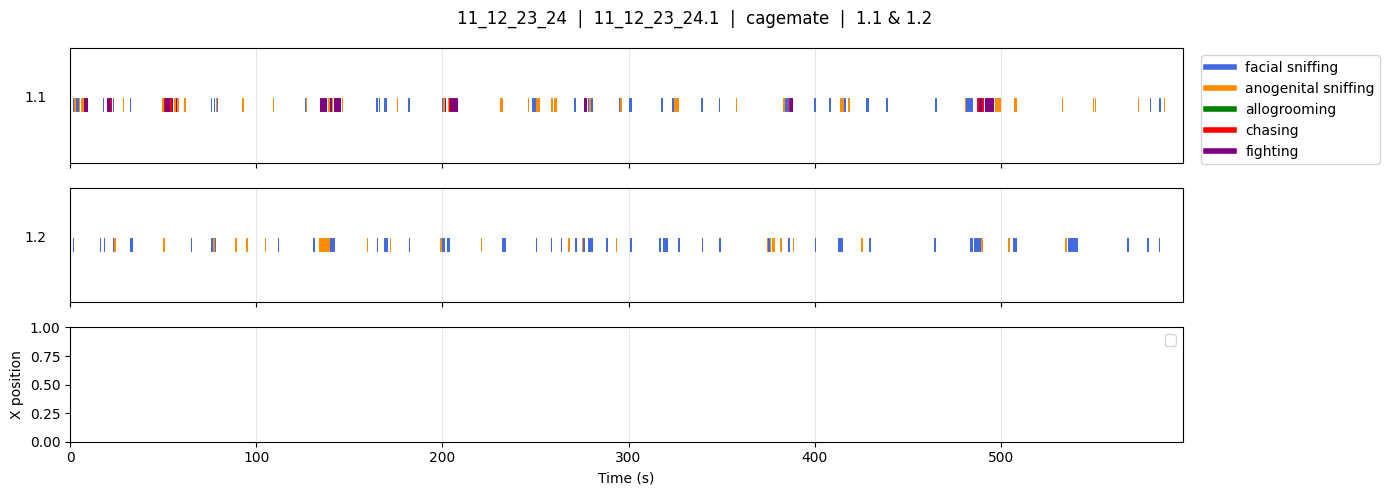

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


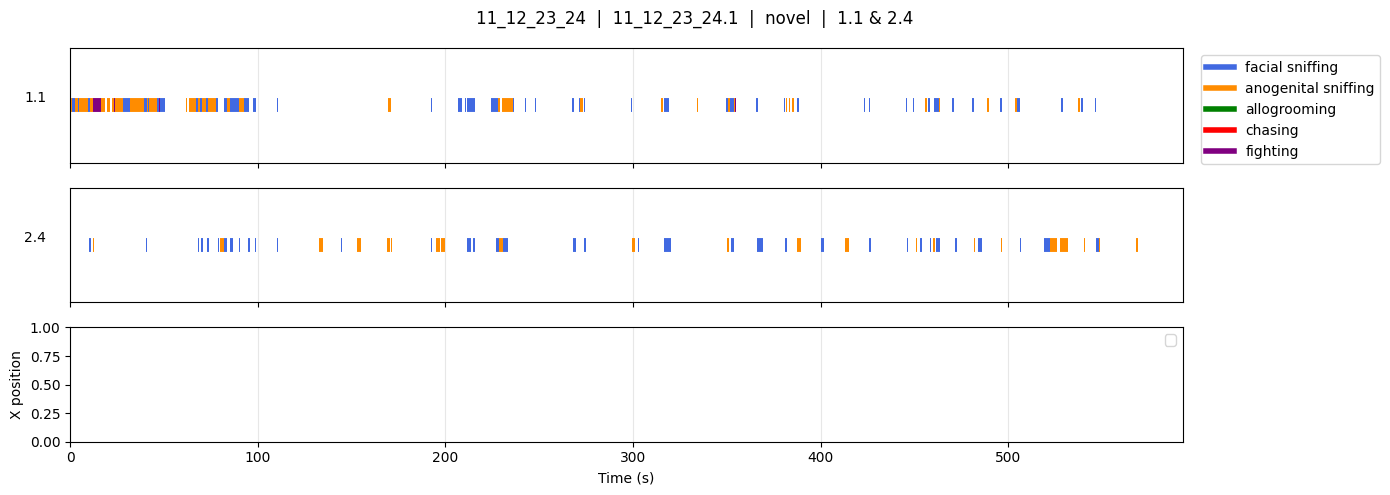

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


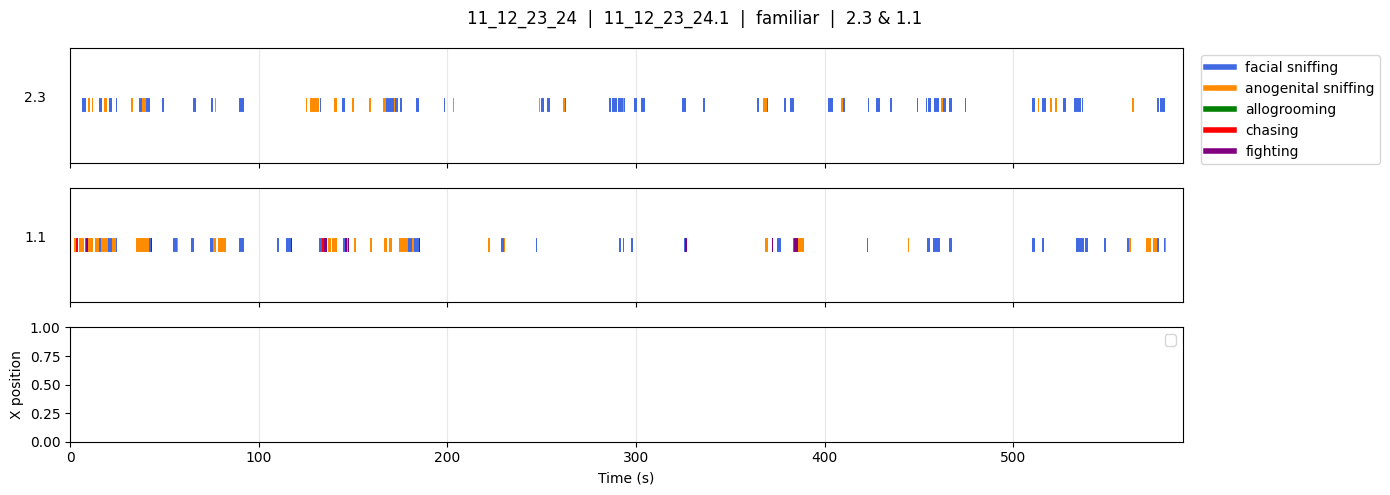

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


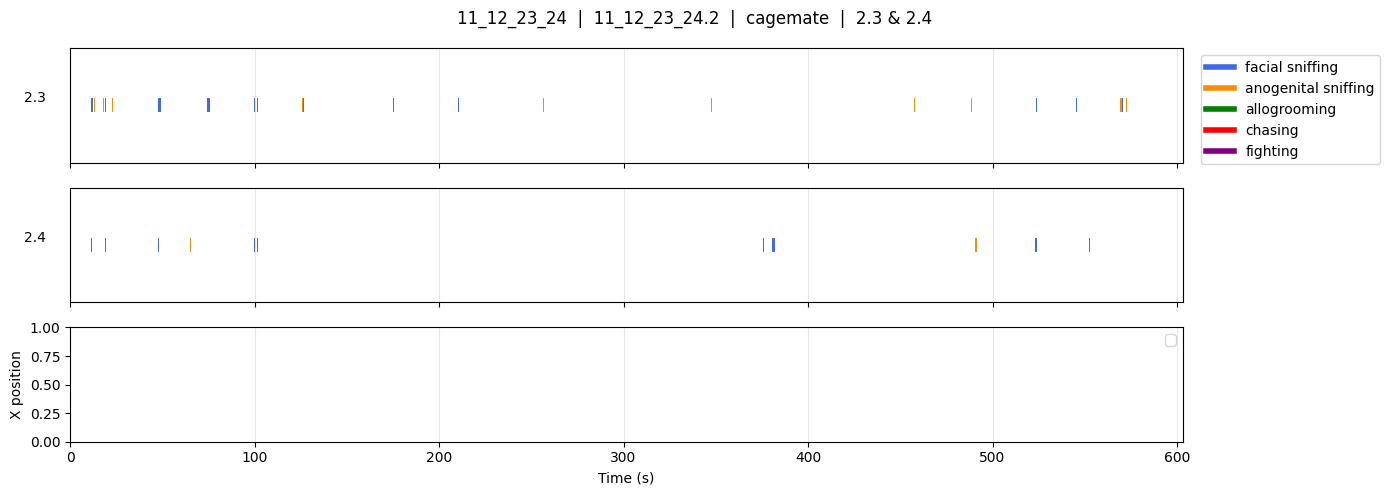

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


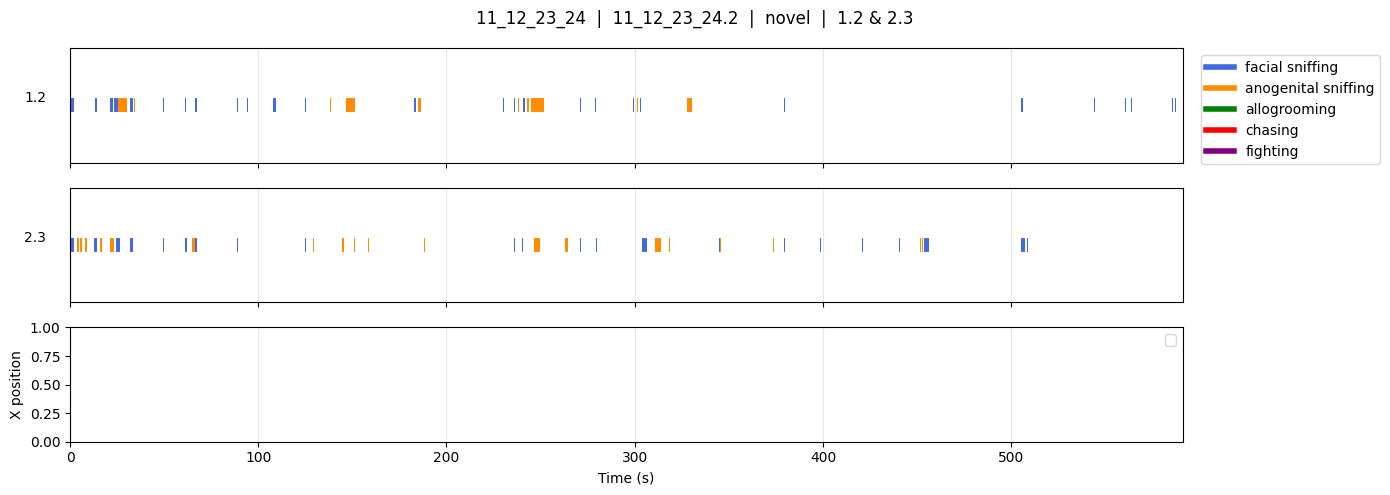

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


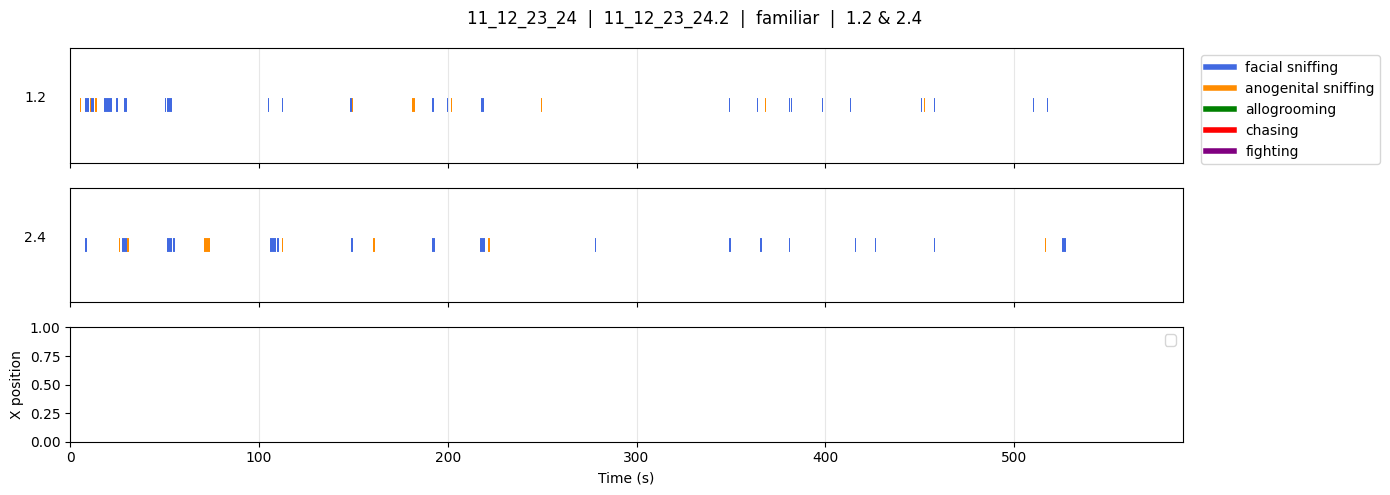

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


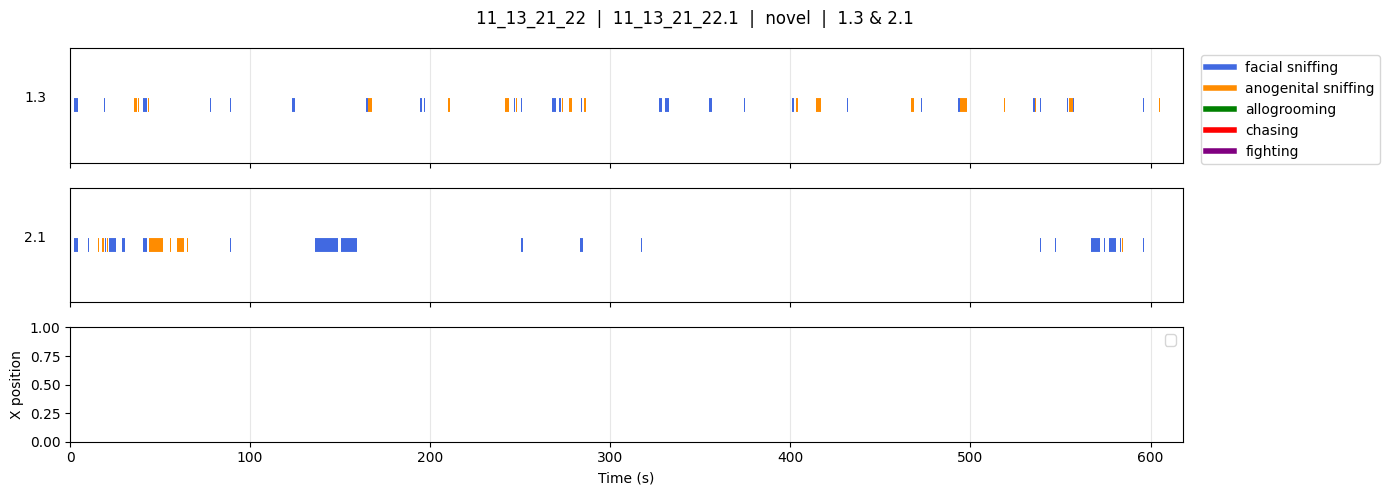

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


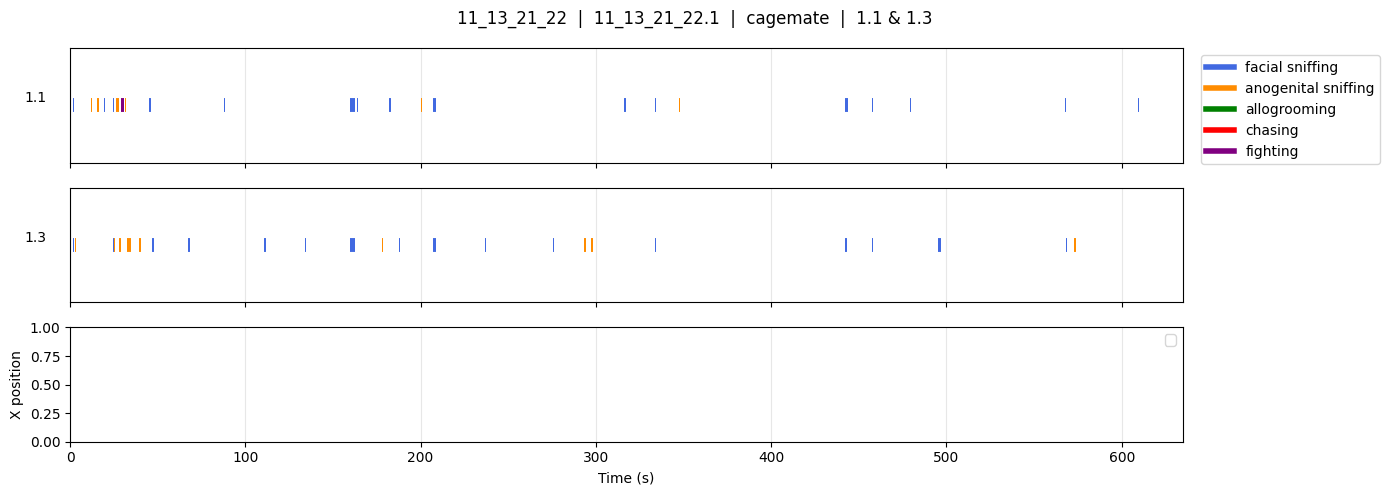

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


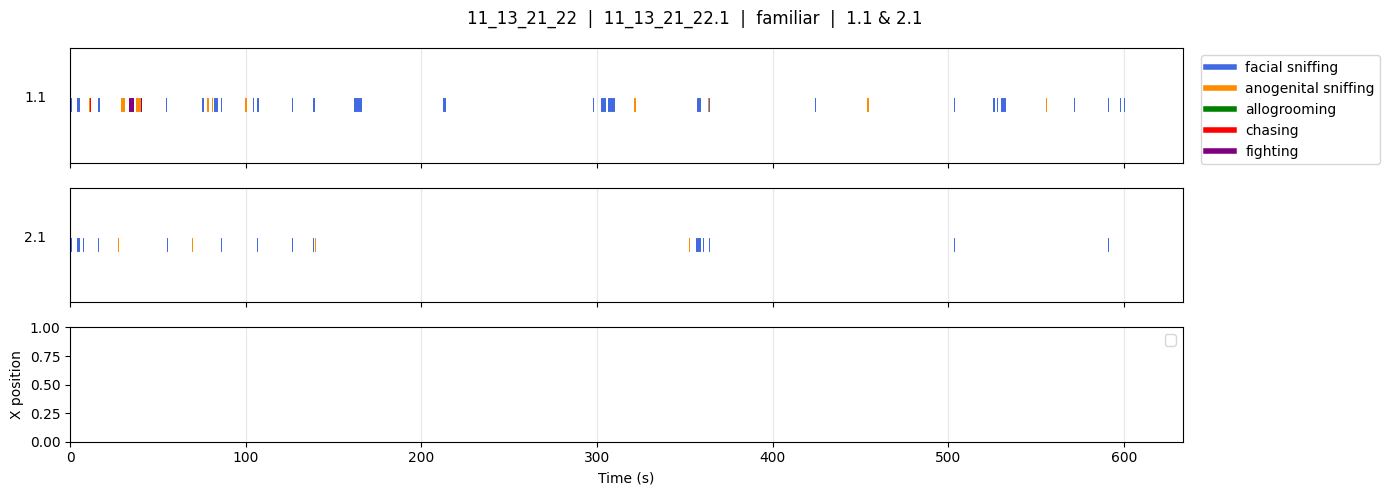

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


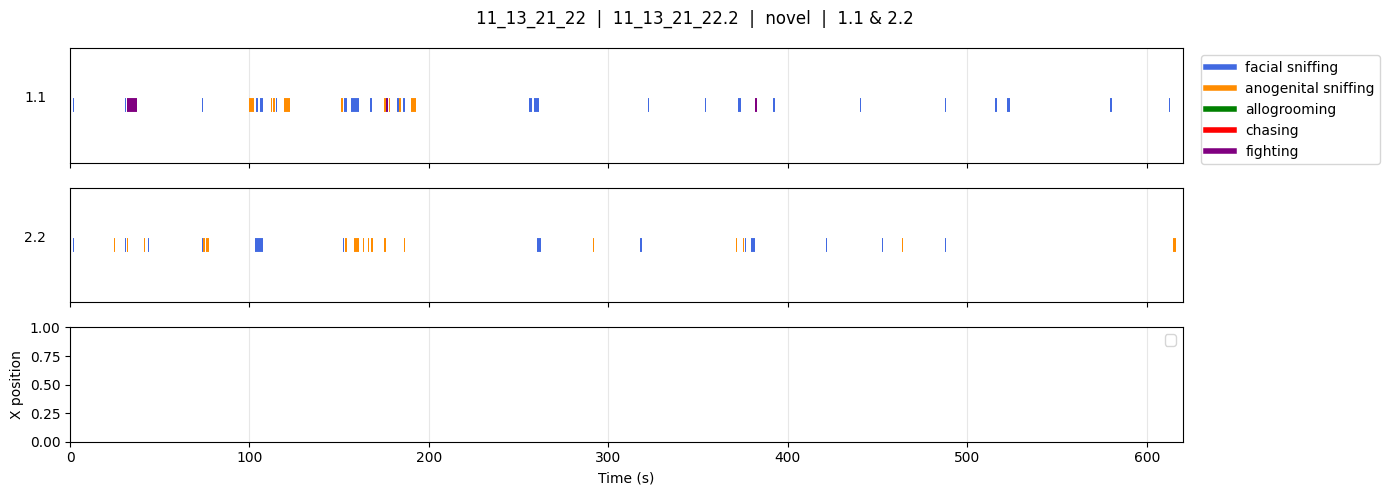

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


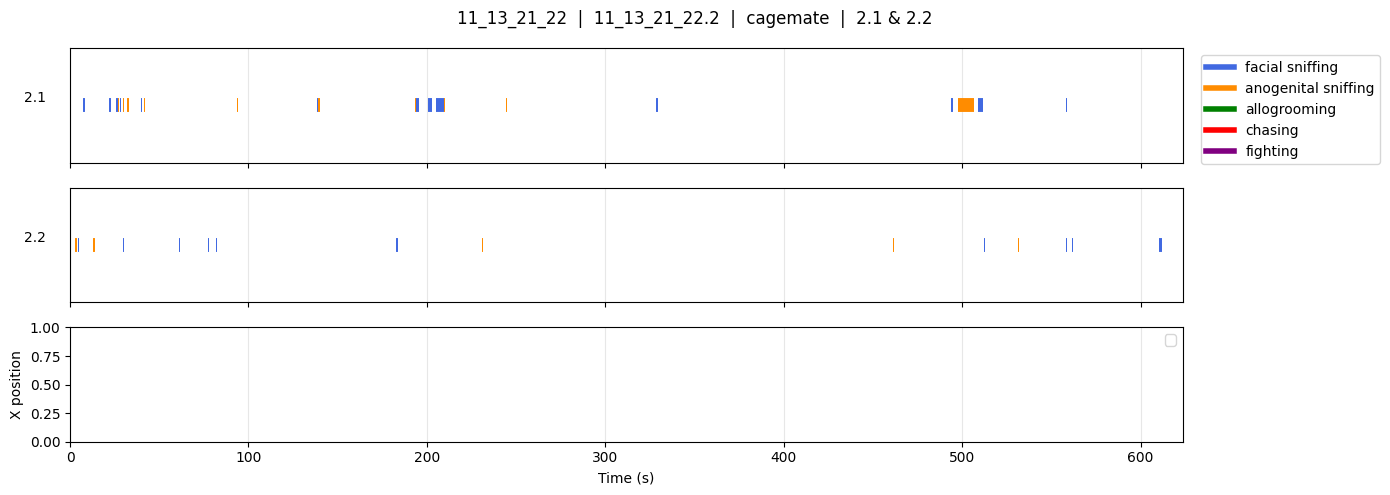

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


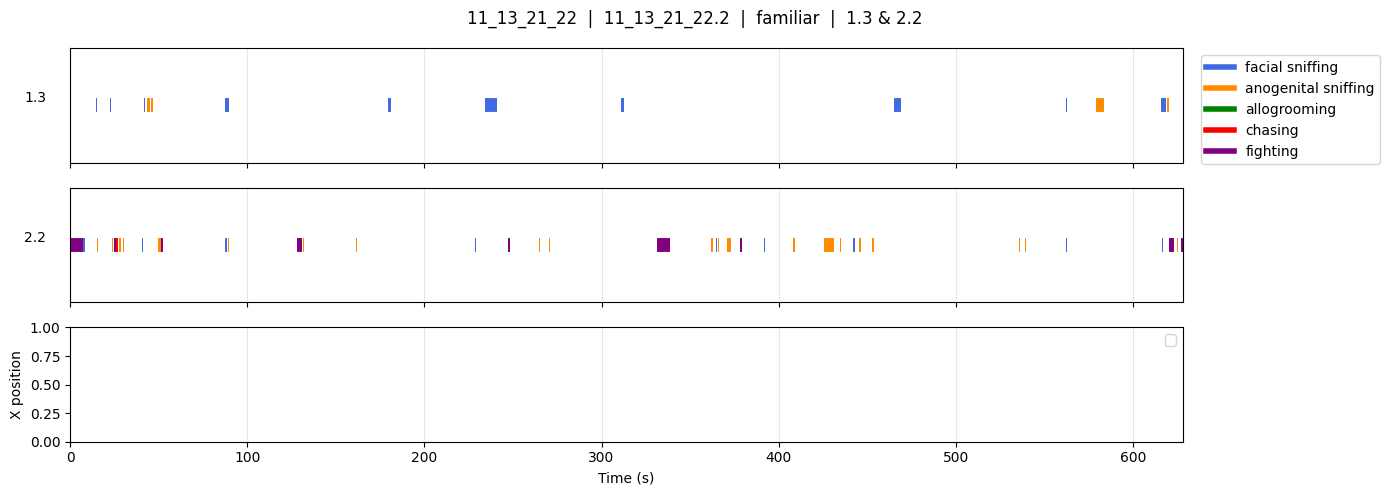

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


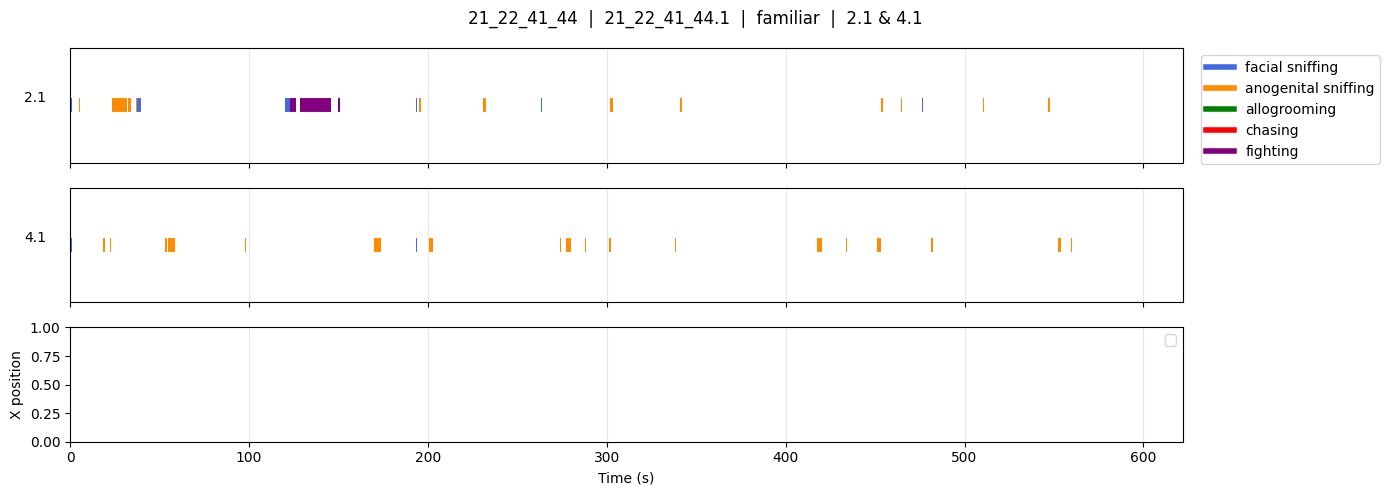

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


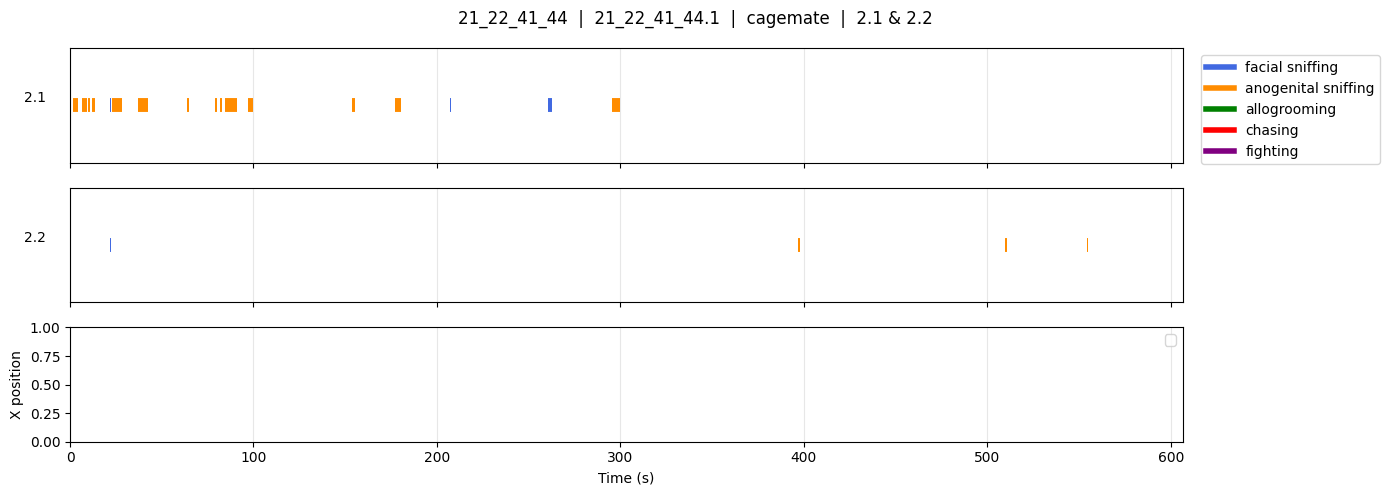

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


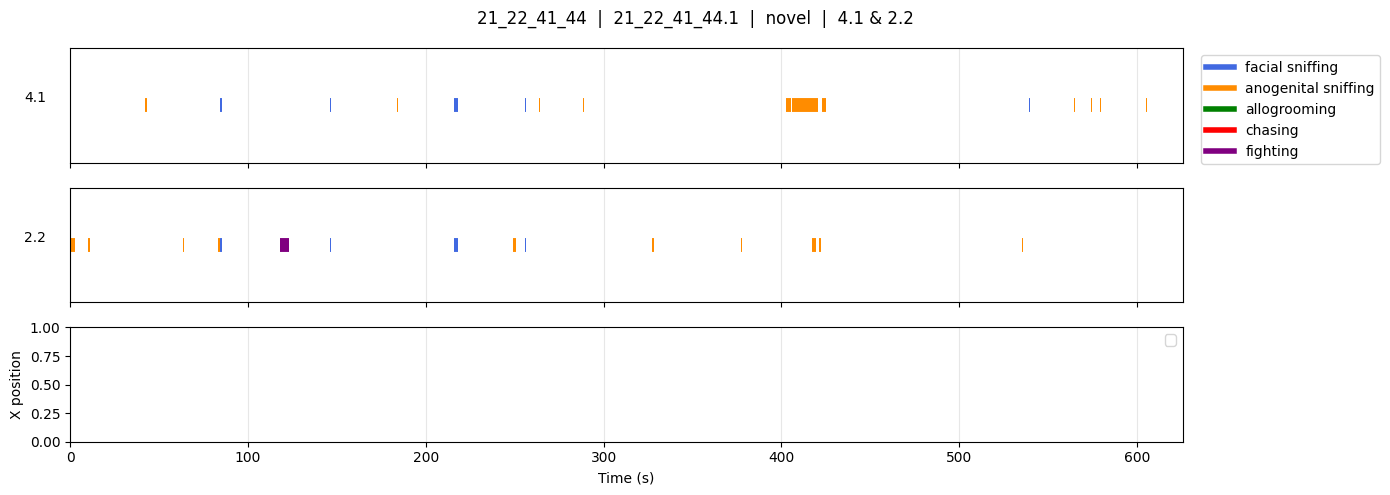

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


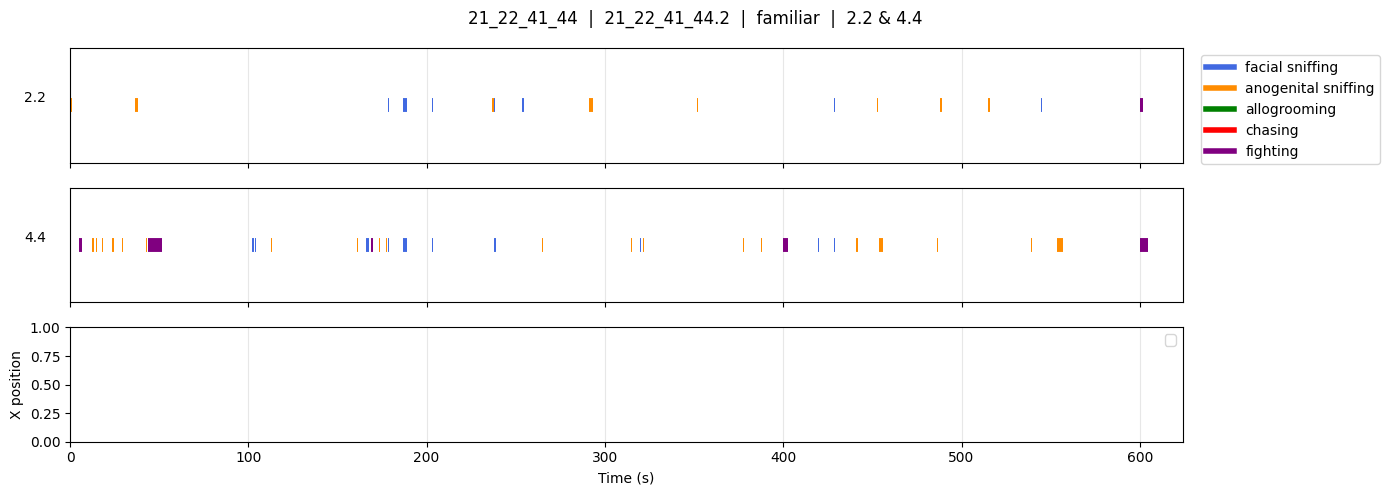

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


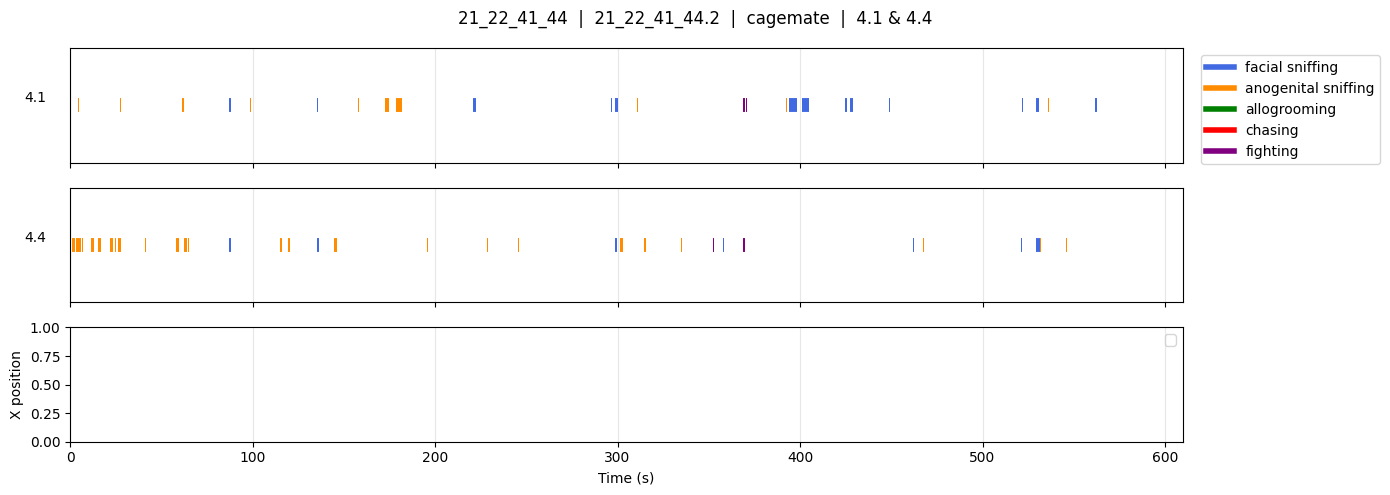

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


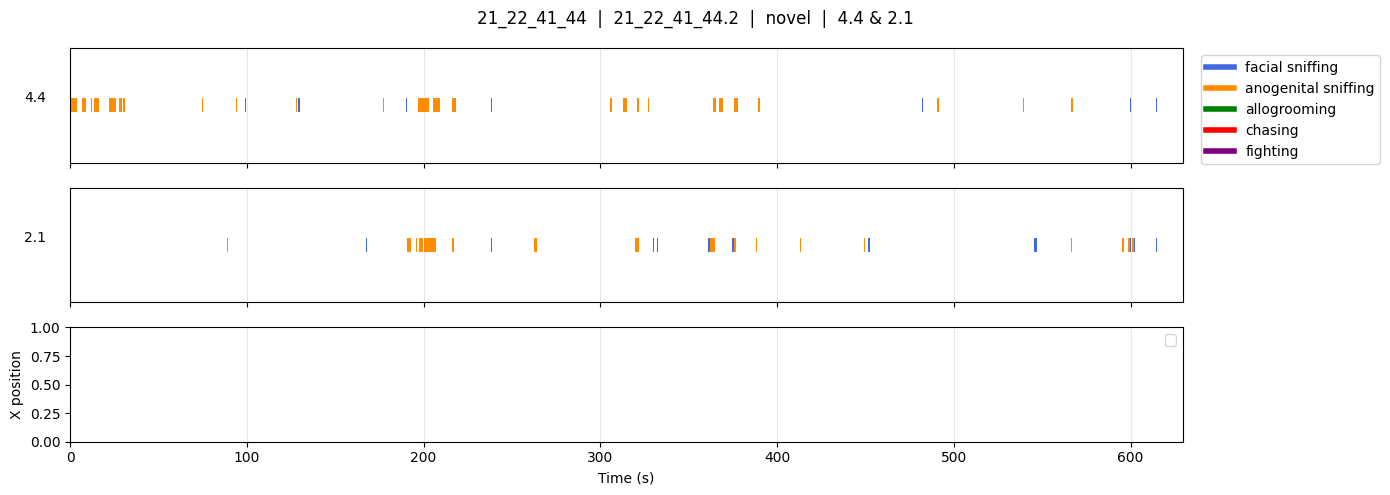

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


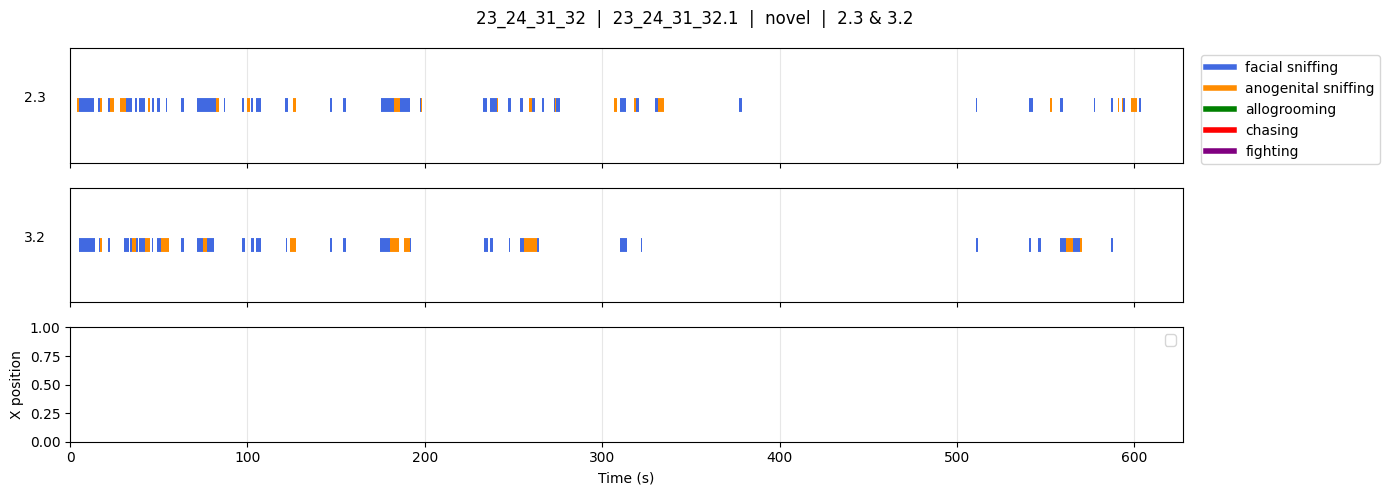

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


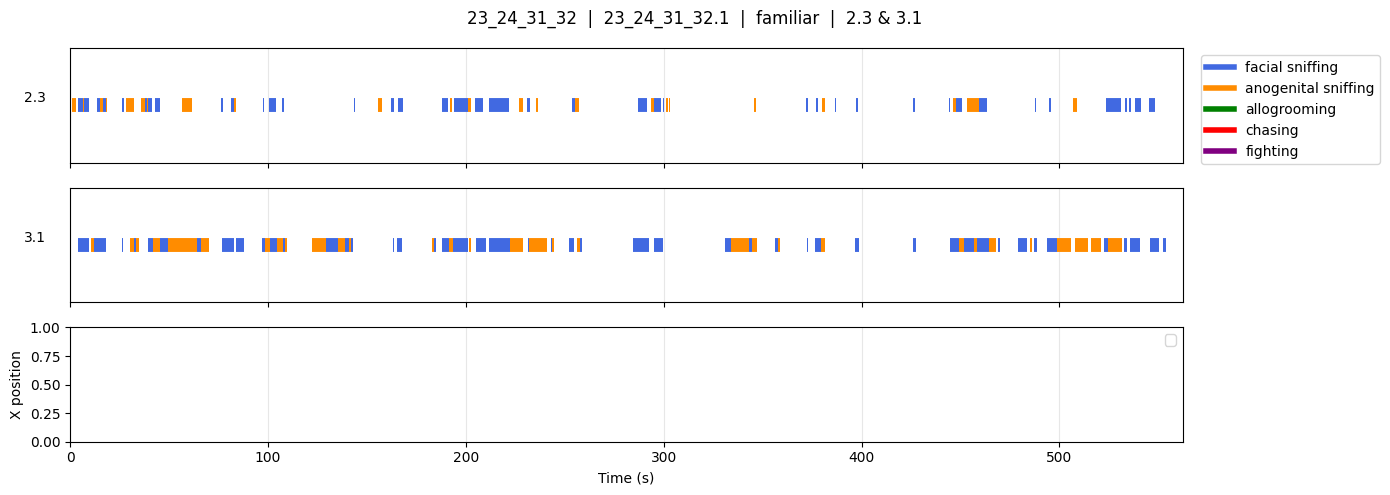

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


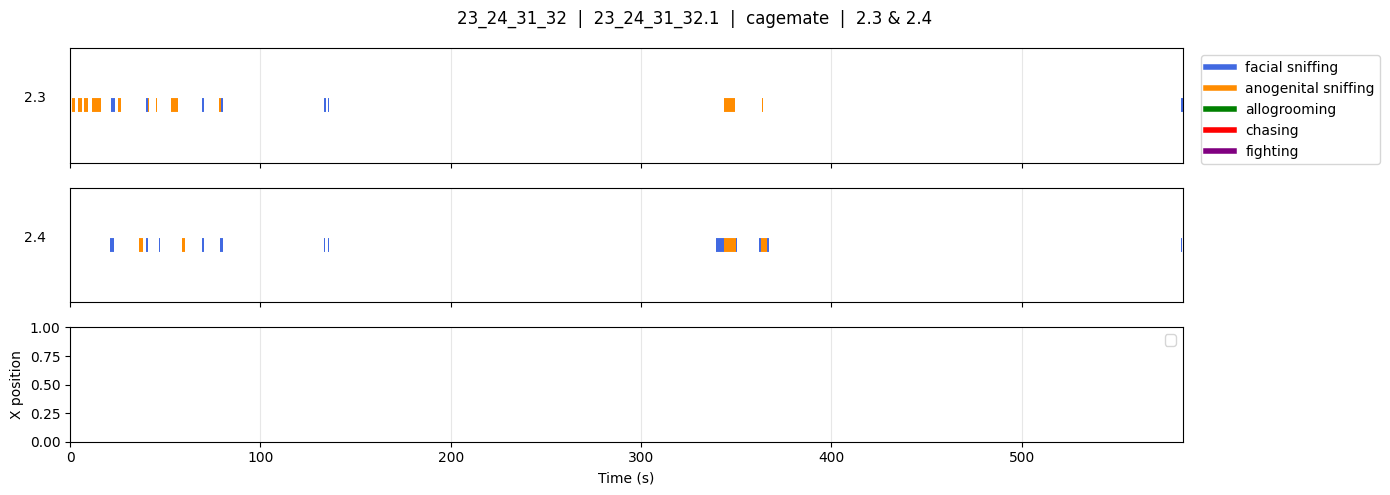

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


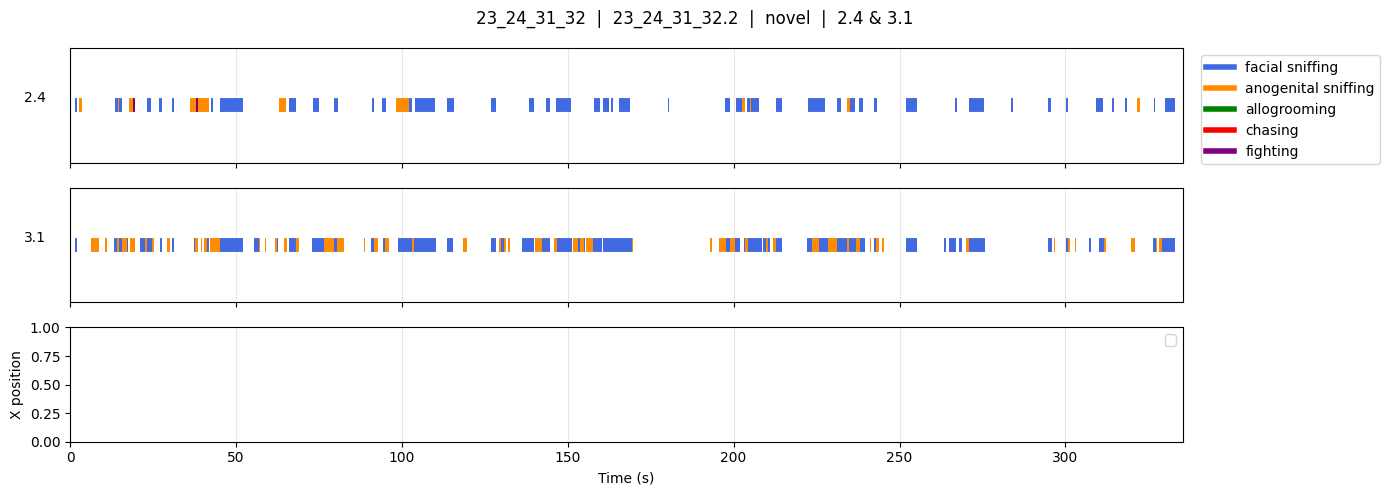

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


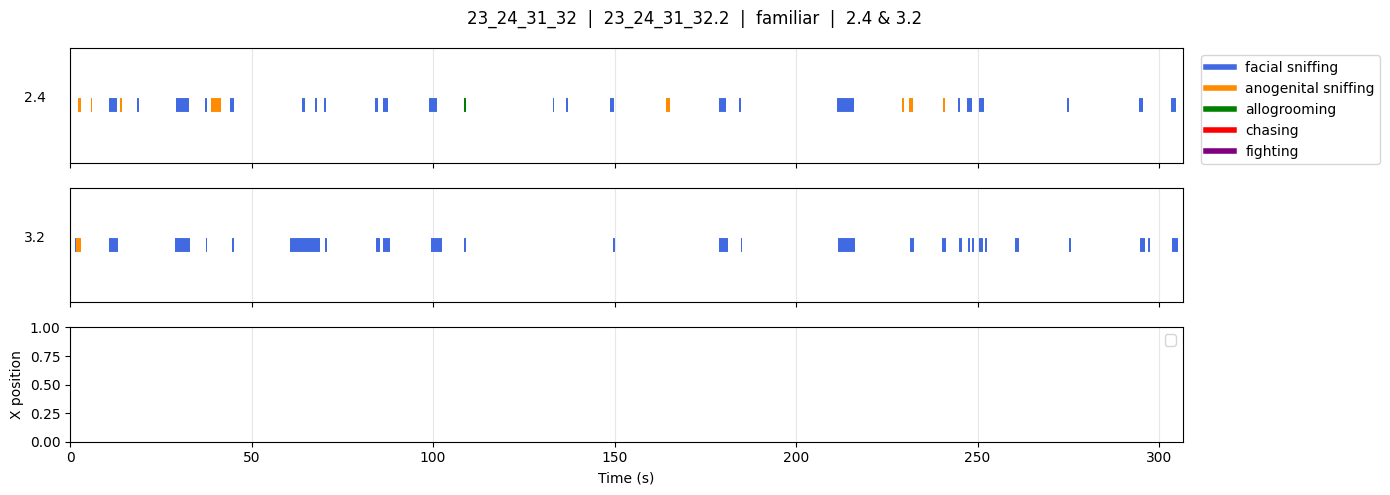

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


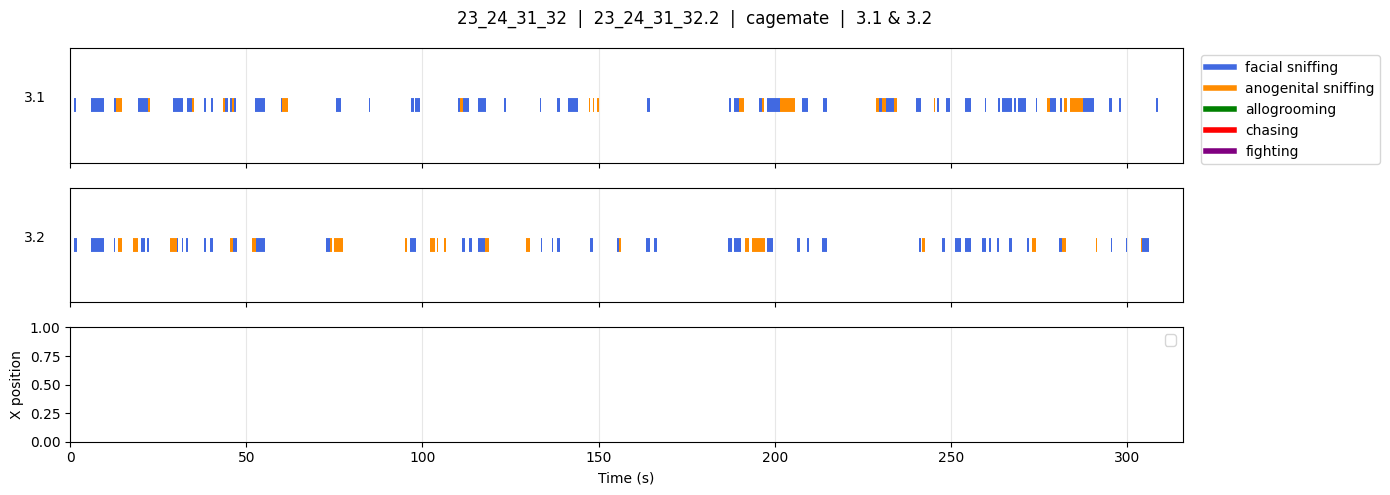

In [220]:

epoch_pairs = {                                                                                                                                                                                                                                                         
      '23_24_31_32.1': [('2.3', '3.2'), ('2.3', '3.1'), ('2.3', '2.4')],                                                                                                                                                                                                  
      '23_24_31_32.2': [('2.4', '3.1'), ('2.4', '3.2'), ('3.1', '3.2')],                                                                                                                                                                                                  
      '21_22_41_44.1': [('2.1', '4.1'), ('2.1', '2.2'), ('4.1', '2.2')],                                                                                                                                                                                                  
      '21_22_41_44.2': [('2.2', '4.4'), ('4.1', '4.4'), ('4.4', '2.1')],                                                                                                                                                                                                  
      '11_13_21_22.1': [('1.3', '2.1'), ('1.1', '1.3'), ('1.1', '2.1')],                                                                                                                                                                                                  
      '11_13_21_22.2': [('1.1', '2.2'), ('2.1', '2.2'), ('1.3', '2.2')],                                                                                                                                                                                                  
      '11_12_23_24.1': [('1.1', '1.2'), ('1.1', '2.4'), ('2.3', '1.1')],                                                                                                                                                                                                  
      '11_12_23_24.2': [('2.3', '2.4'), ('1.2', '2.3'), ('1.2', '2.4')],                                                                                                                                                                                                  
  }         
common_to_recs = {}                                                                                                                                                                                                                                                     
for rec_pair in pairs:                  
    common = rec_pair[0].split('.')[0]                                                                                                                                                                                                                                  
    common_to_recs[common] = list(rec_pair)
def plot_pairwise_ethogram(label_array, sleap, common_to_recs, epoch_pairs, order_dict, behavior_key, behavior_colors):                                                                                                                                                                           
      inv_behavior_key = {v: k for k, v in behavior_key.items() if k != 'none'}
      track_colors = ['steelblue', 'tomato']

      for common, recs in common_to_recs.items():
          order = order_dict[common]

          for rec in recs:
              rec_key = rec.replace('.csv', '')

              for agent, epoch_idx in order.items():
                  s1, s2 = epoch_pairs[rec_key][epoch_idx - 1]

                  entry1 = label_array[common].get(s1, {}).get(agent)
                  entry2 = label_array[common].get(s2, {}).get(agent)

                  if entry1 is None and entry2 is None:
                      continue

                  arr1   = entry1['behavior'] if entry1 is not None else None
                  arr2   = entry2['behavior'] if entry2 is not None else None
                  fps1   = entry1['fps']      if entry1 is not None else entry2['fps']
                  fps2   = entry2['fps']      if entry2 is not None else entry1['fps']

                  pos1 = sleap[common].get(s1, {}).get(agent)
                  pos2 = sleap[common].get(s2, {}).get(agent)

                  fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
                  fig.suptitle(f'{common}  |  {rec_key}  |  {agent}  |  {s1} & {s2}')

                  for ax, s_key, behavior_array, fps, color in zip(
                          axes[:2], [s1, s2], [arr1, arr2], [fps1, fps2], track_colors):
                      ax.set_ylabel(s_key, rotation=0, labelpad=25)
                      ax.set_yticks([])
                      ax.grid(True, axis='x', alpha=0.3)

                      if behavior_array is None:
                          continue

                      for behavior_val, behavior_name in inv_behavior_key.items():
                          is_beh = (behavior_array == behavior_val).astype(int)
                          changes = np.diff(is_beh, prepend=0, append=0)
                          starts = np.where(changes == 1)[0] / fps
                          ends   = np.where(changes == -1)[0] / fps
                          for s, e in zip(starts, ends):
                              ax.plot([s, e], [0, 0],
                                      color=behavior_colors[behavior_name], linewidth=10, solid_capstyle='butt')

                      ax.set_xlim(0, len(behavior_array) / fps)
                      ax.set_ylim(-0.5, 0.5)

                  ax_pos = axes[2]
                  ax_pos.set_ylabel('X position')
                  ax_pos.grid(True, axis='x', alpha=0.3)
                  for s_key, pos, fps, color in zip([s1, s2], [pos1, pos2], [fps1, fps2], track_colors):
                      if pos is not None:
                          t = np.arange(len(pos)) / fps
                          ax_pos.plot(t, pos[:, 8, 0], color=color, linewidth=0.8, label=s_key)
                  ax_pos.legend(loc='upper right')
                  ax_pos.set_xlabel('Time (s)')

                  legend_handles = [plt.Line2D([0], [0], color=c, lw=4, label=b)
                                    for b, c in behavior_colors.items()]
                  axes[0].legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')
                  plt.tight_layout()
                  plt.show()
                                                                                                                                                                                                                                                                          
plot_pairwise_ethogram(label_array, sleap, common_to_recs, epoch_pairs, order_dict, behavior_key, behavior_colors) 

In [221]:
def count_nonsocial_windows(label_array, epoch_pairs, order_dict, common_to_recs, window_s=2.5):                                                                                                                                                                                                    
      """                                                                                                                                                                                                                                                                                           
      For each (common, rec, agent), count how many non-overlapping windows of
      window_s seconds fit in the frames where both paired subjects are zero.
      """
      results = []

      for common, recs in common_to_recs.items():
          order = order_dict[common]

          for rec in recs:
              rec_key = rec.replace('.csv', '')

              for agent, epoch_idx in order.items():
                  s1, s2 = epoch_pairs[rec_key][epoch_idx - 1]

                  entry1 = label_array[common].get(s1, {}).get(agent)
                  entry2 = label_array[common].get(s2, {}).get(agent)

                  if entry1 is None or entry2 is None:
                      continue

                  fps = entry1['fps']
                  window_frames = int(window_s * fps)

                  zero_mask = (entry1['behavior'] == 0) & (entry2['behavior'] == 0)

                  # find contiguous zero spans
                  changes = np.diff(zero_mask.astype(int), prepend=0, append=0)
                  span_starts = np.where(changes == 1)[0]
                  span_ends   = np.where(changes == -1)[0]

                  n_windows = sum(
                      (end - start) // window_frames
                      for start, end in zip(span_starts, span_ends)
                  )

                  results.append({
                      'common': common, 'rec': rec_key, 'agent': agent,
                      'epoch length': label_array[common][s1][agent]['epoch'][1] - label_array[common][s1][agent]['epoch'][0],
                      's1': s1, 's2': s2,
                      'zero_frames': zero_mask.sum(),
                      'zero_s': zero_mask.sum() / fps,
                      'n_windows': n_windows
                  })
                  print(f"{rec_key} | {agent} | {s1}&{s2}: "
                        f"{zero_mask.sum()/fps:.1f}s quiet, {n_windows} windows @ {window_s}s with epoch length {(label_array[common][s1][agent]['epoch'][1] - label_array[common][s1][agent]['epoch'][0])/fps/60:.1f}min at {fps}fps")

      return results

counts = count_nonsocial_windows(label_array, epoch_pairs, order_dict, common_to_recs, window_s=2.5)

11_12_23_24.1 | cagemate | 1.1&1.2: 436.7s quiet, 139 windows @ 2.5s with epoch length 10.0min at 15fps
11_12_23_24.1 | novel | 1.1&2.4: 405.7s quiet, 133 windows @ 2.5s with epoch length 9.9min at 15fps
11_12_23_24.1 | familiar | 2.3&1.1: 405.1s quiet, 131 windows @ 2.5s with epoch length 9.8min at 15fps
11_12_23_24.2 | cagemate | 2.3&2.4: 581.3s quiet, 218 windows @ 2.5s with epoch length 10.1min at 15fps
11_12_23_24.2 | novel | 1.2&2.3: 514.4s quiet, 180 windows @ 2.5s with epoch length 9.9min at 15fps
11_12_23_24.2 | familiar | 1.2&2.4: 535.3s quiet, 196 windows @ 2.5s with epoch length 9.8min at 15fps
11_13_21_22.1 | novel | 1.3&2.1: 506.8s quiet, 177 windows @ 2.5s with epoch length 10.3min at 15fps
11_13_21_22.1 | cagemate | 1.1&1.3: 595.9s quiet, 224 windows @ 2.5s with epoch length 10.6min at 15fps
11_13_21_22.1 | familiar | 1.1&2.1: 577.6s quiet, 213 windows @ 2.5s with epoch length 10.6min at 15fps
11_13_21_22.2 | novel | 1.1&2.2: 551.9s quiet, 199 windows @ 2.5s with epoch 

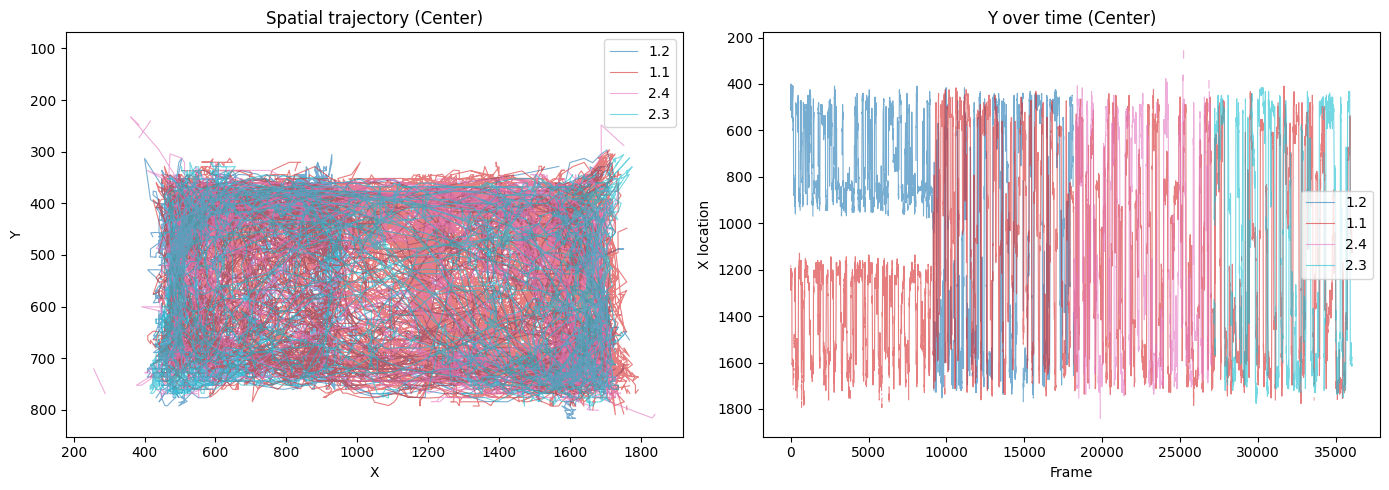

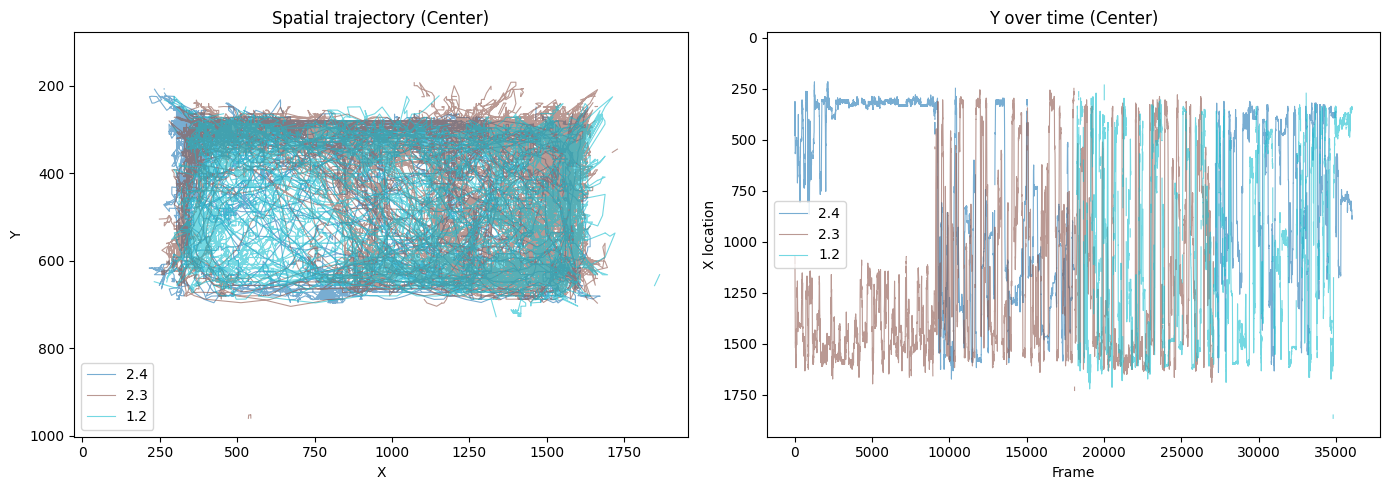

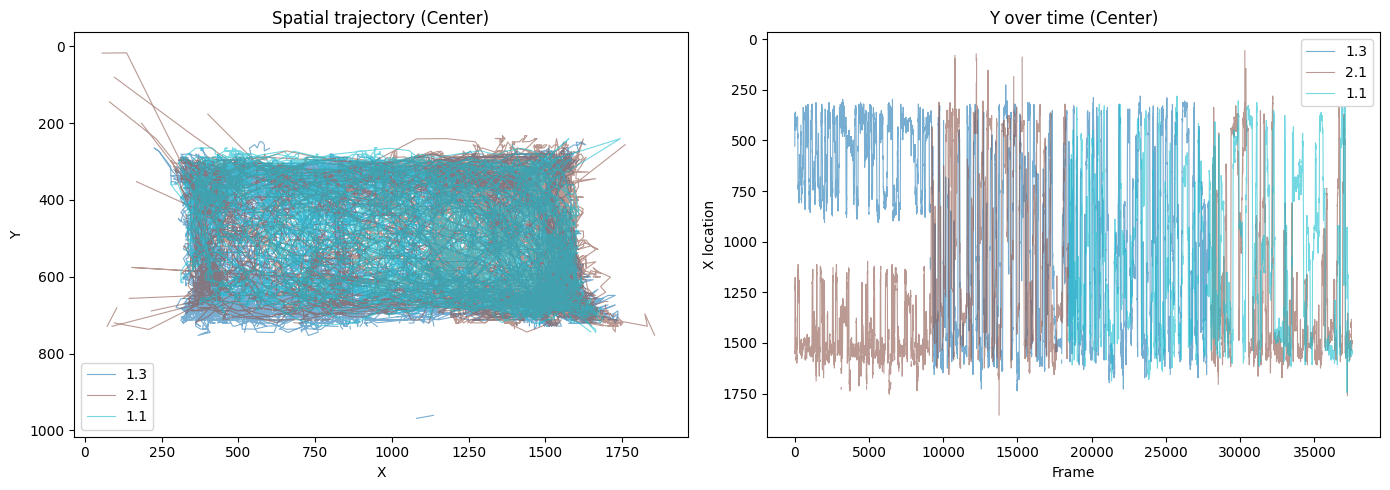

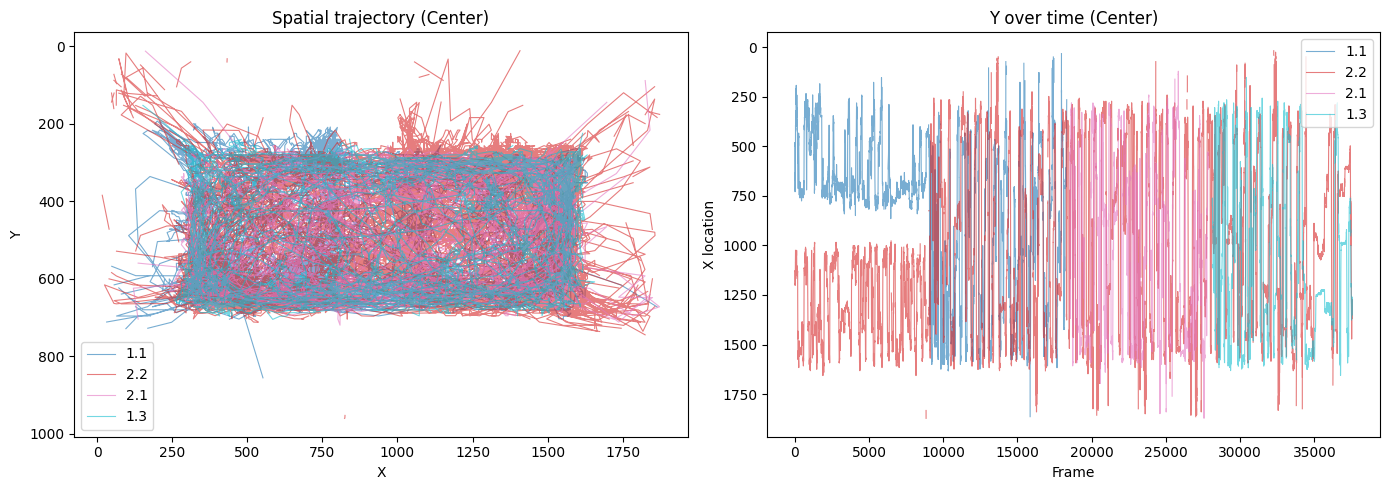

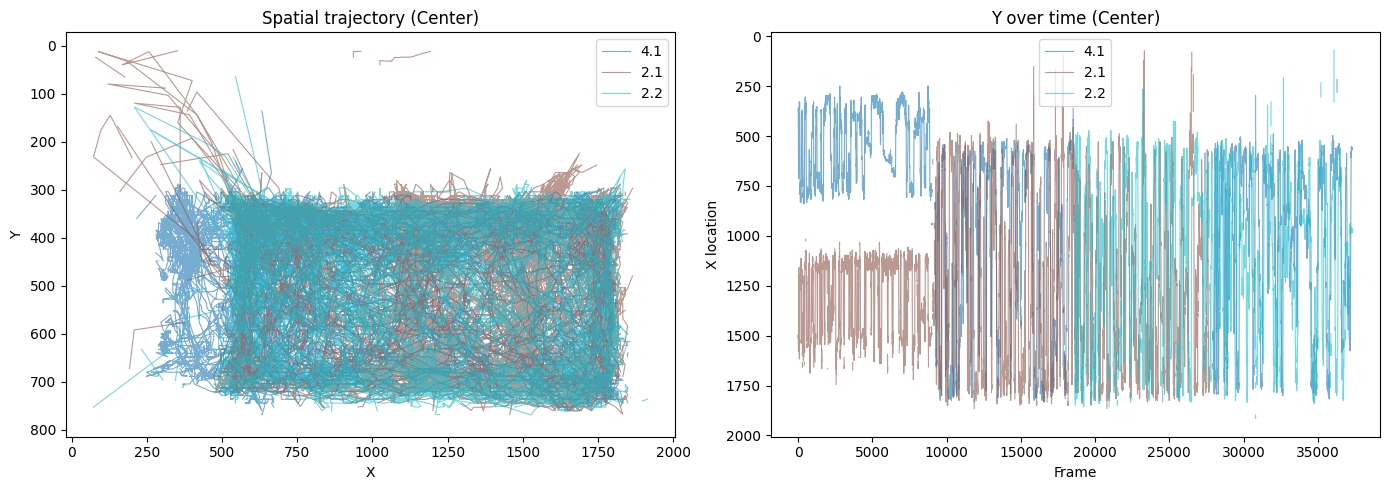

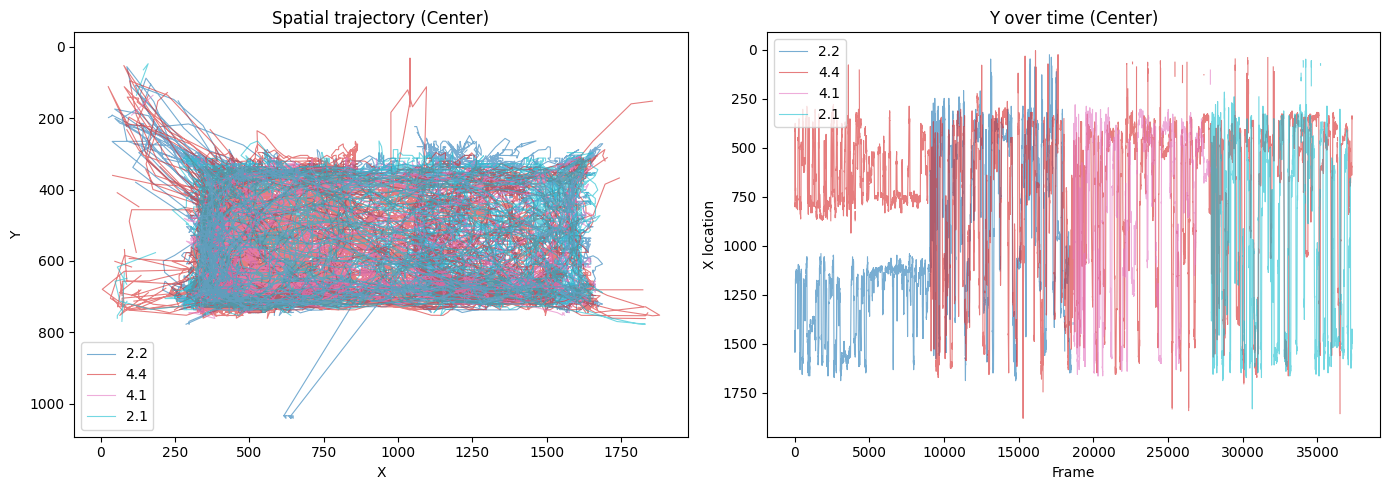

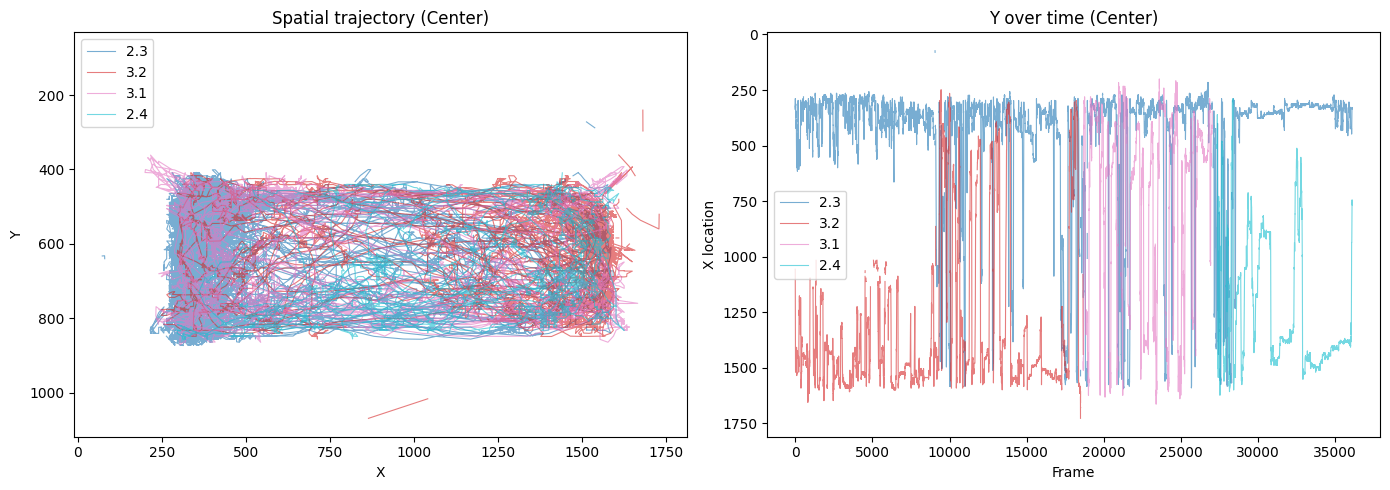

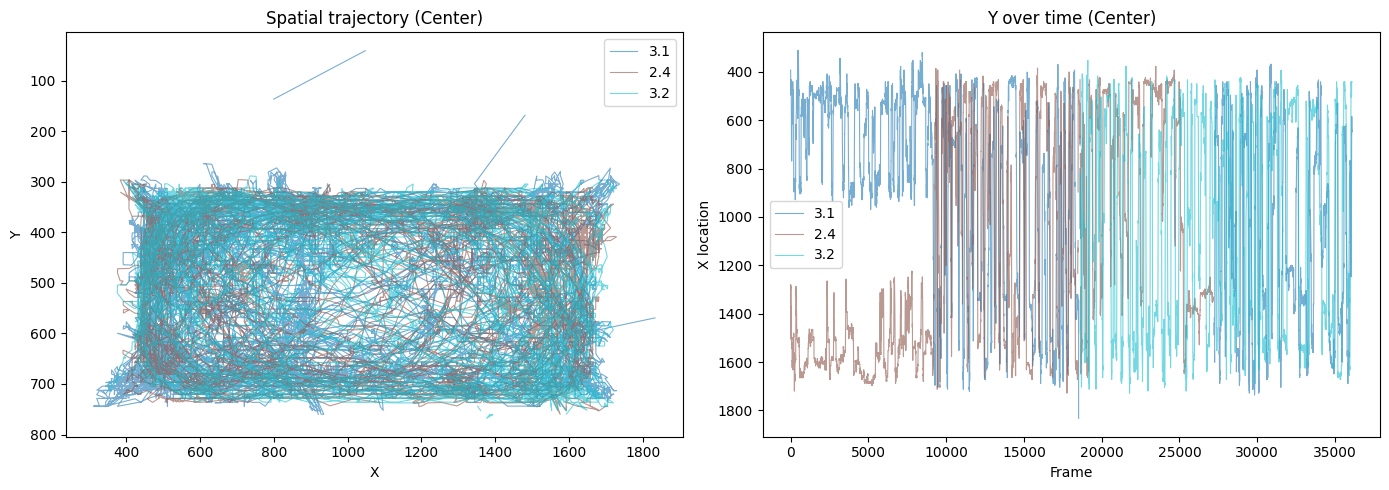

In [222]:
def plot_tracks(sleap_obj, node="Center", figsize=(14, 5)):                                                                             
      """                                                                                                                                 
      Two-panel track visualization.                                                                                                      
      Left:  X vs Y spatial trajectory for each track
      Right: Frame (time) vs Y location for each track                                                                                    
                                                                                                                                          
      Args:                                                                                                                               
          sleap_obj: sleap_vid instance                                                                                                   
          node: str, node name to plot (default "Center")
          figsize: tuple
      """                                                                                                                                 
      node_idx = sleap_obj.node_dict[node]
      n_tracks = len(sleap_obj.tracks)                                                                                                    
      frames = np.arange(sleap_obj.locations.shape[0])
                                                                                                                                          
      colors = plt.cm.tab10(np.linspace(0, 1, n_tracks))
      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)                                                                               
                                                                                                                                          
      for i, track_name in enumerate(sleap_obj.tracks):
          x = sleap_obj.locations[:, node_idx, 0, i]                                                                                      
          y = sleap_obj.locations[:, node_idx, 1, i]                                                                                      
   
          # Left: spatial trajectory                                                                                                      
          ax1.plot(x, y, color=colors[i], label=track_name, alpha=0.6, linewidth=0.8)
                                                                                                                                          
          # Right: time vs Y               
          ax2.plot(frames, x, color=colors[i], label=track_name, alpha=0.6, linewidth=0.8)                                                
                                                                                                                                          
      ax1.set_xlabel("X")
      ax1.set_ylabel("Y")                                                                                                                 
      ax1.set_title(f"Spatial trajectory ({node})")
      ax1.invert_yaxis()  # image coords: y=0 is top                                                                                      
      ax1.legend()                                                                                                                        
                                                                                                                                          
      ax2.set_xlabel("Frame")                                                                                                             
      ax2.set_ylabel("X location")         
      ax2.set_title(f"Y over time ({node})")
      ax2.invert_yaxis()                                                                                                                  
      ax2.legend()
                                                                                                                                          
      plt.tight_layout()                   
      plt.show()

for sleap_ob in sleap_objs.values():
    plot_tracks(sleap_ob, node="Center")


In [223]:
# import cv2                                                                                                                                                                                                                                                                                                            
# import matplotlib.pyplot as plt                                                                                                                                                                                                                                                                                       
# import matplotlib.patches as mpatches                                                                                                                                                                                                                                                                                 
# import numpy as np                                                                                                                                                                                                                                                                                                    
# from pathlib import Path                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
# # --- config ---                                                                                                                                                                                                                                                                                                      
# VIDEO_DIR  = r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\SLEAP\only_subjects_mp4s\dark"   # update this
# SWITCH_THRESHOLD = 50   # pixels/frame jump to count as an ID switch
# WINDOW     = 100        # frames before and after switch
# EVERY_NTH  = 10        # plot every nth frame → 200/10 = 20 frames per switch
# GRID_COLS  = 10        # columns in the plot grid

# # ---------------------------------------------------------------
# def detect_id_switches(sleap_obj):                                                                                                                                                                                                                                                                                    
#     """                                                                                                                                                                                                                                                                                                                     Detects frames where one track disappears (valid → all NaN) and                                                                                                                                                                                                                                                   
#     another appears (all NaN → valid) — the classic SLEAP ID swap.                                                                                                                                                                                                                                                          
#     Returns list of (frame, disappeared_tracks, appeared_tracks) tuples.                                                                                                                                                                                                                                              
#     """                                                                                                                                                                                                                                                                                                               
#     locs     = sleap_obj.locations   # (frames, nodes, 2, n_tracks)
#     n_tracks = locs.shape[-1]

#     # True if track has at least one non-NaN node in that frame
#     is_active = ~np.all(np.isnan(locs), axis=(1, 2))   # (frames, n_tracks)

#     # transitions per track
#     # disappeared: was active, now NaN  → diff == -1
#     # appeared:    was NaN, now active  → diff == +1
#     transitions = np.diff(is_active.astype(int), axis=0)   # (frames-1, n_tracks)

#     switches = []
#     for f in range(transitions.shape[0]):
#         disappeared = np.where(transitions[f] == -1)[0]
#         appeared    = np.where(transitions[f] == +1)[0]
#         if len(disappeared) > 0 and len(appeared) > 0:
#             switches.append((f + 1, disappeared.tolist(), appeared.tolist()))

#     return switches


# def overlay_skeleton(ax, sleap_obj, frame_idx, colors):
#     """Draw nodes (and edges if available) for all tracks on ax."""
#     locs = sleap_obj.locations   # (frames, nodes, 2, n_tracks)
#     n_tracks = locs.shape[-1]
#     for t in range(n_tracks):
#         xy = locs[frame_idx, :, :, t]   # (nodes, 2)  — xy[:,0]=x, xy[:,1]=y
#         valid = ~np.isnan(xy[:, 0])
#         ax.scatter(xy[valid, 0], xy[valid, 1],
#                     c=[colors[t]], s=30, zorder=5, linewidths=0)
#         # label node indices so you can tell which keypoint is which
#         for n_idx in np.where(valid)[0]:
#             ax.text(xy[n_idx, 0], xy[n_idx, 1], str(n_idx),
#                     fontsize=5, color=colors[t], zorder=6)


# def plot_switch_window(video_path, sleap_obj, switch_frame,
#                         window=WINDOW, every_nth=EVERY_NTH, grid_cols=GRID_COLS):
#     cap = cv2.VideoCapture(str(video_path))
#     total_vid_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     n_tracks = sleap_obj.locations.shape[-1]
#     colors   = plt.cm.tab10(np.linspace(0, 1, n_tracks))

#     frame_start  = max(0, switch_frame - window)
#     frame_stop   = min(total_vid_frames - 1, sleap_obj.locations.shape[0] - 1,
#                         switch_frame + window)
#     frames_to_plot = list(range(frame_start, frame_stop + 1, every_nth))

#     n_plots   = len(frames_to_plot)
#     grid_rows = int(np.ceil(n_plots / grid_cols))
#     fig, axes = plt.subplots(grid_rows, grid_cols,
#                             figsize=(grid_cols * 2.5, grid_rows * 2.5))
#     axes = np.array(axes).flatten()

#     for i, frame_idx in enumerate(frames_to_plot):
#         ax = axes[i]
#         cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
#         ret, frame = cap.read()
#         if ret:
#             ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
#         overlay_skeleton(ax, sleap_obj, frame_idx, colors)

#         title = f"f={frame_idx}"
#         if frame_idx == switch_frame:
#             title += " ★"
#             for spine in ax.spines.values():
#                 spine.set_edgecolor('red')
#                 spine.set_linewidth(3)
#         ax.set_title(title, fontsize=7)
#         ax.axis('off')

#     # hide unused axes
#     for ax in axes[n_plots:]:
#         ax.axis('off')

#     legend = [mpatches.Patch(color=colors[t], label=sleap_obj.tracks[t])
#             for t in range(n_tracks)]
#     fig.legend(handles=legend, loc='upper right', fontsize=8)
#     fig.suptitle(f"{video_path.stem} — switch at frame {switch_frame}", fontsize=11)
#     plt.tight_layout()
#     plt.show()
#     cap.release()


# # ---------------------------------------------------------------
# # match videos to sleap_objs by name prefix
# video_dir = Path(VIDEO_DIR)

# for video_path in sorted(video_dir.glob("*.mp4")):
#     # e.g. "11_12_21_22.1_converted.mp4" → key "11_12_21_22.1"
#     key = "_".join(video_path.stem.replace("_converted", "").split("_")[:5])
#     # try trimming trailing parts until we find a match
#     parts = video_path.stem.replace("_converted", "").split("_")
#     sleap_key = None
#     for n in range(len(parts), 0, -1):
#         candidate = "_".join(parts[:n])
#         if candidate in sleap_objs:
#             sleap_key = candidate
#             break

#     if sleap_key is None:
#         print(f"No sleap_obj found for {video_path.name}, skipping")
#         continue

#     sleap_obj     = sleap_objs[sleap_key]
#     switches = detect_id_switches(sleap_obj)
#     print(f"\n{video_path.name} → {sleap_key}: {len(switches)} ID switches")
#     for frame, gone, came in switches:
#         gone_names = [sleap_obj.tracks[t] for t in gone]
#         came_names = [sleap_obj.tracks[t] for t in came]
#         print(f"  frame {frame}: {gone_names} disappeared, {came_names} appeared")
#         plot_switch_window(video_path, sleap_obj, frame)

In [224]:
def plot_tracks_crowded(sleap_obj, node="Center", min_tracks=3, figsize=(14, 5)):                                                                                                                                                                                                                                                                              
    n_tracks = sleap_obj.locations.shape[-1]                                                                                                                                                                                                                                                                          
    n_frames = sleap_obj.locations.shape[0]
    colors   = plt.cm.tab10(np.linspace(0, 1, n_tracks))

    # count valid tracks per frame: a track is present if any node is non-NaN
    # locations shape: (frames, nodes, 2, n_tracks)
    track_present = ~np.all(np.isnan(sleap_obj.locations), axis=(1, 2))  # (frames, n_tracks)
    n_valid = track_present.sum(axis=1)                                   # (frames,)

    crowded = n_valid >= min_tracks                                        # bool mask
    if not crowded.any():
        print(f"No frames with >= {min_tracks} tracks.")
        return

    # find contiguous crowded segments
    changes    = np.diff(crowded.astype(int), prepend=0, append=0)
    starts     = np.where(changes == 1)[0]
    stops      = np.where(changes == -1)[0]

    print(f"{len(starts)} crowded segment(s), {crowded.sum()} frames total "
        f"({100*crowded.mean():.1f}% of recording)")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    for i in range(n_tracks):
        track_name = sleap_obj.tracks[i]
        x_all = sleap_obj.locations[:, node_idx, 0, i]
        y_all = sleap_obj.locations[:, node_idx, 1, i]

        for seg_start, seg_stop in zip(starts, stops):
            x = x_all[seg_start:seg_stop]
            y = y_all[seg_start:seg_stop]
            frames = np.arange(seg_start, seg_stop)

            ax1.plot(x, y, color=colors[i], alpha=0.6, linewidth=0.8,
                    label=track_name if seg_start == starts[0] else "")
            ax2.plot(frames, x, color=colors[i], alpha=0.6, linewidth=0.8,
                    label=track_name if seg_start == starts[0] else "")

    ax1.set_xlabel("X");  ax1.set_ylabel("Y")
    ax1.set_title(f"Spatial trajectory ({node}) — crowded frames only")
    ax2.set_xlabel("Frame"); ax2.set_ylabel("X position")
    ax2.set_title(f"Time vs X — crowded frames only")
    ax1.legend(); ax2.legend()
    plt.tight_layout()
    plt.show()

for name, sleap_ob in sleap_objs.items():
    print(f"\n=== {name} ===")
    plot_tracks_crowded(sleap_ob, node="Center", min_tracks=3)


=== 11_12_23_24.1 ===
No frames with >= 3 tracks.

=== 11_12_23_24.2 ===
No frames with >= 3 tracks.

=== 11_13_21_22.1 ===
No frames with >= 3 tracks.

=== 11_13_21_22.2 ===
No frames with >= 3 tracks.

=== 21_22_41_44.1 ===
No frames with >= 3 tracks.

=== 21_22_41_44.2 ===
No frames with >= 3 tracks.

=== 23_24_31_32.1 ===
No frames with >= 3 tracks.

=== 23_24_31_32.2 ===
No frames with >= 3 tracks.


In [225]:
boris_dfs

{'11_12_23_24.1.csv':     Observation id Observation date  Description  \
 0    11_12_23_24.1  4/30/2025 13:28          NaN   
 1    11_12_23_24.1  4/30/2025 13:28          NaN   
 2    11_12_23_24.1  4/30/2025 13:28          NaN   
 3    11_12_23_24.1  4/30/2025 13:28          NaN   
 4    11_12_23_24.1  4/30/2025 13:28          NaN   
 ..             ...              ...          ...   
 493  11_12_23_24.1  4/30/2025 13:28          NaN   
 494  11_12_23_24.1  4/30/2025 13:28          NaN   
 495  11_12_23_24.1  4/30/2025 13:28          NaN   
 496  11_12_23_24.1  4/30/2025 13:28          NaN   
 497  11_12_23_24.1  4/30/2025 13:28          NaN   
 
                                             Media file  Total length  FPS  \
 0    /Volumes/LAB WORK/Research Lab/BORIS/April 30/...        4804.8   15   
 1    /Volumes/LAB WORK/Research Lab/BORIS/April 30/...        4804.8   15   
 2    /Volumes/LAB WORK/Research Lab/BORIS/April 30/...        4804.8   15   
 3    /Volumes/LAB WORK/Resea

In [226]:
sleap_objs

{'11_12_23_24.1': <__main__.sleap_vid at 0x1a98f5517b0>,
 '11_12_23_24.2': <__main__.sleap_vid at 0x1a98d5c8d90>,
 '11_13_21_22.1': <__main__.sleap_vid at 0x1a98f553fd0>,
 '11_13_21_22.2': <__main__.sleap_vid at 0x1a98f550190>,
 '21_22_41_44.1': <__main__.sleap_vid at 0x1a98f551c90>,
 '21_22_41_44.2': <__main__.sleap_vid at 0x1a98f553190>,
 '23_24_31_32.1': <__main__.sleap_vid at 0x1a98f552d40>,
 '23_24_31_32.2': <__main__.sleap_vid at 0x1a98f553f10>}

In [227]:
LETTER_TO_EPOCH = {
    'C': 'cagemate',
    'N': 'novel',
    'F': 'familiar'
}

def parse_ins_outs(rec_dict, order):
    """
    Takes ins_outs[common] and an order string like 'CNF'
    and returns a dict mapping epoch name to (in_s, out_s).

    Parameters
    ----------
    rec_dict : dict  — ins_outs[common], keyed by rec name
    order    : str   — e.g. 'CNF', 'NCF', 'FCN', 'NFC'

    Returns
    -------
    dict: { 'cagemate': (in_s, out_s), 'novel': (in_s, out_s), 'familiar': (in_s, None) }
    """
    epoch_bounds = {}

    for rec, (ins, outs) in rec_dict.items():
        epoch_bounds[rec] = {}
        for i, letter in enumerate(order):
            epoch = LETTER_TO_EPOCH[letter]
            in_s  = ins[i]*1000
            out_s = outs[i]*1000 if i < len(outs) else None  # last epoch has no out
            epoch_bounds[rec][epoch] = (in_s, out_s)

    return epoch_bounds



In [228]:
agent_abbrev = {'cagemate': 'C', 'novel': 'N', 'familiar': 'F'}                                                                                                                                                                                                                                     
def behavior_to_1ms(behavior_array, timestamps_ms, start_ms=None, stop_ms=None):                                                                                                                                                                                                                    
      """                                                                                                                                                                                                                                                                                             
      Resample a per-frame behavior label array into 1ms bins by forward-filling,                                                                                                                                                                                                                     
      using the same logic as sleap_to_1ms.                                                                                                                                                                                                                                                         

      Parameters
      ----------
      behavior_array : (n_frames,) int  — per-frame behavior labels
      timestamps_ms  : (n_frames,) float — real timestamp in ms for each video frame
                       (should already be epoch-sliced, i.e. timestamps_ms[epoch_start:epoch_stop])
      start_ms       : first ms bin (default: floor of first timestamp)
      stop_ms        : last ms bin  (default: ceil of last timestamp)

      Returns
      -------
      dict:
          'behavior_1ms' : (n_ms_bins,) int
          'time_ms'      : (n_ms_bins,) int — absolute ms index of each bin
      """
      if start_ms is None:
          start_ms = int(np.floor(timestamps_ms[0]))
      if stop_ms is None:
          stop_ms = int(np.ceil(timestamps_ms[-1]))

      time_ms = np.arange(start_ms, stop_ms + 1)
      frame_indices = np.searchsorted(timestamps_ms, time_ms, side='right') - 1
      frame_indices = np.clip(frame_indices, 0, len(behavior_array) - 1)

      return {
          'behavior_1ms': behavior_array[frame_indices],
          'time_ms': time_ms,
      }                                                                                                                                                                                                                                                                                                    
def get_order_abbrev(order):                                                                                                                                                                                                                                                                        
    """{'cagemate': 1, 'novel': 2, 'familiar': 3} -> 'CNF'"""                                                                                                                                                                                                                                     
    return ''.join(agent_abbrev[a] for a, _ in sorted(order.items(), key=lambda x: x[1]))                                                                                                                                                                                                         

for common, subjects in label_array.items():
    order_abbrev = get_order_abbrev(order_dict[common])

    for s_key, agents in subjects.items():
        subject_num = s_key.replace('.', '')
        ft_key = f'{subject_num}_{order_abbrev}'

        if ft_key not in first_timestamp_dict:
            print(f'WARNING: no first_timestamp for {ft_key}, skipping')
            continue

        first_timestamp_ms = first_timestamp_dict[ft_key] / 20

        for agent, entry in agents.items():
            if not isinstance(entry, dict):
                continue

            rec_name = entry['rec']
            if rec_name not in timestamps_dict:
                print(f'WARNING: no timestamps for {rec_name}, skipping')
                continue

            timestamps_ms = (timestamps_dict[rec_name] * 1000) - first_timestamp_ms

            epoch_start, epoch_stop = entry['epoch']
            epoch_timestamps = timestamps_ms[epoch_start:epoch_stop]

            if len(epoch_timestamps) != len(entry['behavior']):
                print(f'WARNING: {common} {s_key} {agent}: '
                    f'epoch_len={len(epoch_timestamps)} != behavior_len={len(entry["behavior"])}')

            result = behavior_to_1ms(entry['behavior'], epoch_timestamps)
            entry['behavior_1ms'] = result['behavior_1ms']
            entry['time_ms']      = result['time_ms']

            print(f'{common} {s_key} {agent}: {len(result["behavior_1ms"])/1000:.1f}s @ 1ms')




11_12_23_24 1.1 cagemate: 597.6s @ 1ms
11_12_23_24 1.1 novel: 592.9s @ 1ms
11_12_23_24 1.1 familiar: 589.8s @ 1ms
11_12_23_24 1.2 cagemate: 597.6s @ 1ms
11_12_23_24 1.2 novel: 591.1s @ 1ms
11_12_23_24 1.2 familiar: 589.2s @ 1ms
11_12_23_24 2.3 familiar: 589.8s @ 1ms
11_12_23_24 2.3 cagemate: 603.0s @ 1ms
11_12_23_24 2.3 novel: 591.1s @ 1ms
11_12_23_24 2.4 novel: 592.9s @ 1ms
11_12_23_24 2.4 cagemate: 603.0s @ 1ms
11_12_23_24 2.4 familiar: 589.2s @ 1ms
11_13_21_22 1.1 cagemate: 634.7s @ 1ms
11_13_21_22 1.1 familiar: 633.3s @ 1ms
11_13_21_22 1.1 novel: 620.0s @ 1ms
11_13_21_22 1.3 novel: 617.8s @ 1ms
11_13_21_22 1.3 cagemate: 634.7s @ 1ms
11_13_21_22 1.3 familiar: 628.0s @ 1ms
11_13_21_22 2.1 novel: 617.8s @ 1ms
11_13_21_22 2.1 familiar: 633.3s @ 1ms
11_13_21_22 2.1 cagemate: 623.5s @ 1ms
11_13_21_22 2.2 novel: 620.0s @ 1ms
11_13_21_22 2.2 cagemate: 623.5s @ 1ms
11_13_21_22 2.2 familiar: 628.0s @ 1ms
21_22_41_44 2.1 familiar: 621.8s @ 1ms
21_22_41_44 2.1 cagemate: 606.5s @ 1ms
21_22_41_4

In [229]:
def get_nonsocial_epochs(label_array, epoch_pairs, order_dict, common_to_recs, window_ms=2500):                                                                                                                                                                                                     
      """                                                                                                                                                                                                                                                                                             
      For each (common, rec, agent) pair, AND both paired subjects' behavior_1ms arrays                                                                                                                                                                                                               
      to find frames where neither is doing anything. Tile those spans with non-overlapping                                                                                                                                                                                                           
      windows of window_ms and store start/stop in each subject's ephys time reference.                                                                                                                                                                                                             

      Returns
      -------
      non_social[common][s_key][agent] = np.array([[start_ms, stop_ms], ...])
      """
      non_social = {}

      for common, recs in common_to_recs.items():
          non_social.setdefault(common, {})
          order = order_dict[common]

          for rec in recs:
              rec_key = rec.replace('.csv', '')

              for agent, epoch_idx in order.items():
                  s1, s2 = epoch_pairs[rec_key][epoch_idx - 1]

                  entry1 = label_array[common].get(s1, {}).get(agent)
                  entry2 = label_array[common].get(s2, {}).get(agent)

                  if not isinstance(entry1, dict) or not isinstance(entry2, dict):
                      continue
                  if 'behavior_1ms' not in entry1 or 'behavior_1ms' not in entry2:
                      print(f'  SKIP {common} {s1}&{s2} {agent}: missing behavior_1ms')
                      continue

                  b1, t1 = entry1['behavior_1ms'], entry1['time_ms']
                  b2, t2 = entry2['behavior_1ms'], entry2['time_ms']

                  min_len   = min(len(b1), len(b2))
                  zero_mask = (b1[:min_len] == 0) & (b2[:min_len] == 0)

                  # find contiguous zero spans and tile with windows
                  changes     = np.diff(zero_mask.astype(int), prepend=0, append=0)
                  span_starts = np.where(changes == 1)[0]
                  span_ends   = np.where(changes == -1)[0]

                  windows = []
                  for span_s, span_e in zip(span_starts, span_ends):
                      n = (span_e - span_s) // window_ms
                      for i in range(n):
                          w_s = span_s + i * window_ms
                          w_e = w_s + window_ms          # exclusive end index
                          windows.append((w_s, w_e))

                  if not windows:
                      print(f'  {common} {s1}&{s2} {agent}: no windows found')
                      continue

                  windows = np.array(windows)  # (n_windows, 2)

                  # convert indices -> absolute ms for each subject separately
                  for s_key, t in [(s1, t1), (s2, t2)]:
                      t = t[:min_len]
                      starts_ms = t[windows[:, 0]]
                      stops_ms  = t[windows[:, 1] - 1]   # -1: last ms bin inside window
                      arr = np.stack([starts_ms, stops_ms], axis=1)

                      non_social[common].setdefault(s_key, {})
                      if agent in non_social[common][s_key]:
                          non_social[common][s_key][agent] = np.vstack(
                              [non_social[common][s_key][agent], arr])
                      else:
                          non_social[common][s_key][agent] = arr

                      print(f'  {common} {s_key} {agent}: {len(arr)} x {window_ms}ms windows')

      return non_social

non_social = get_nonsocial_epochs(label_array, epoch_pairs, order_dict, common_to_recs, window_ms=2500)

  11_12_23_24 1.1 cagemate: 134 x 2500ms windows
  11_12_23_24 1.2 cagemate: 134 x 2500ms windows
  11_12_23_24 1.1 novel: 132 x 2500ms windows
  11_12_23_24 2.4 novel: 132 x 2500ms windows
  11_12_23_24 2.3 familiar: 128 x 2500ms windows
  11_12_23_24 1.1 familiar: 128 x 2500ms windows
  11_12_23_24 2.3 cagemate: 216 x 2500ms windows
  11_12_23_24 2.4 cagemate: 216 x 2500ms windows
  11_12_23_24 1.2 novel: 176 x 2500ms windows
  11_12_23_24 2.3 novel: 176 x 2500ms windows
  11_12_23_24 1.2 familiar: 192 x 2500ms windows
  11_12_23_24 2.4 familiar: 192 x 2500ms windows
  11_13_21_22 1.3 novel: 173 x 2500ms windows
  11_13_21_22 2.1 novel: 173 x 2500ms windows
  11_13_21_22 1.1 cagemate: 218 x 2500ms windows
  11_13_21_22 1.3 cagemate: 218 x 2500ms windows
  11_13_21_22 1.1 familiar: 212 x 2500ms windows
  11_13_21_22 2.1 familiar: 212 x 2500ms windows
  11_13_21_22 1.1 novel: 196 x 2500ms windows
  11_13_21_22 2.2 novel: 196 x 2500ms windows
  11_13_21_22 2.1 cagemate: 214 x 2500ms win

In [230]:
def sample_uniform_windows(windows, n_events):                                                                                                                                                                                                                                                    
      """                                                                                                                                                                                                                                                                                           
      Sample n_events windows with uniform distribution across the epoch.

      Parameters
      ----------
      windows : np.ndarray, shape (n_windows, 2)
          Array of [start_ms, stop_ms] viable windows.
      n_events : int
          Number of windows to select.

      Returns
      -------
      np.ndarray, shape (n_events, 2) or fewer if not enough windows exist.
      """
      if len(windows) == 0:
          return np.empty((0, 2))
      if n_events >= len(windows):
          return windows

      # Use window start times as the position along the epoch
      starts = windows[:, 0]
      epoch_start = starts[0]
      epoch_end   = starts[-1]

      # Evenly spaced target times across the epoch
      targets = np.linspace(epoch_start, epoch_end, n_events)

      # For each target, pick the closest available window (without replacement)
      selected_indices = []
      available = list(range(len(windows)))

      for target in targets:
          avail_starts = starts[available]
          closest = available[np.argmin(np.abs(avail_starts - target))]
          selected_indices.append(closest)
          available.remove(closest)

      return windows[sorted(selected_indices)]

non_social_dict = {}
order_dict_common = {'23_24_31_32': "NFC",  '21_22_41_44': "FCN", '11_13_21_22': "NCF", '11_12_23_24': "CNF" }                                                                                                                                                                                                                                                        

for common in non_social:
    for s_key in non_social[common]:
        subject = s_key.replace(".","")
        rec_name = f"{subject}_{order_dict_common[common]}_merged.rec"
        non_social_dict[rec_name] = {}
        for agent in non_social[common][s_key]:
            selected = sample_uniform_windows(non_social[common][s_key][agent], n_events=15)
            non_social_dict[rec_name][f'non_social_{agent}'] = selected


11_12_23_24.1.csv
  saving 1.1 cagemate from 11_12_23_24.1.csv
  saving 1.1 novel from 11_12_23_24.1.csv
  saving 1.1 familiar from 11_12_23_24.1.csv
  saving 1.2 cagemate from 11_12_23_24.1.csv
  saving 2.3 familiar from 11_12_23_24.1.csv
  saving 2.4 novel from 11_12_23_24.1.csv
11_12_23_24.2.csv
  saving 1.2 novel from 11_12_23_24.2.csv
  saving 1.2 familiar from 11_12_23_24.2.csv
  saving 2.3 cagemate from 11_12_23_24.2.csv
  saving 2.3 novel from 11_12_23_24.2.csv
  saving 2.4 cagemate from 11_12_23_24.2.csv
  saving 2.4 familiar from 11_12_23_24.2.csv
11_CNF_merged.rec ['cagemate', 'novel', 'familiar']
12_CNF_merged.rec ['cagemate', 'novel', 'familiar']
23_CNF_merged.rec ['familiar', 'cagemate', 'novel']
24_CNF_merged.rec ['novel', 'cagemate', 'familiar']


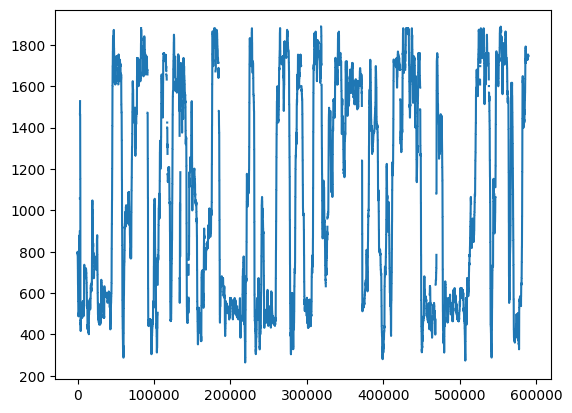

In [231]:



def sleap_to_1ms(sleap_array, timestamps_ms, start_ms=None, stop_ms=None):
    """
    Resample (frames, nodes, axes) into 1ms bins by forward-filling.

    Parameters
    ----------
    sleap_dict    : 'locations': [n_frames, nodes, axes]
                    'first_timestamp': int
    timestamps_ms : (n_frames,) camera timestamps in ms
    start_ms : first ms bin (default: floor of first timestamp)
    stop_ms   : last ms bin  (default: ceil of last timestamp)

    Returns
    -------
    dict:
        'locations_1ms' : (n_ms_bins, nodes, axes) — forward filled
        'frame_index'   : (n_ms_bins,) int — which original frame each bin came from
        'time_ms'       : (n_ms_bins,) int — ms index of each bin
    """
    if start_ms is None:
        start_ms = int(np.floor(timestamps_ms[0]))
    if stop_ms is None:
        stop_ms = int(np.ceil(timestamps_ms[-1]))

    n_bins    = stop_ms - start_ms + 1
    time_ms   = np.arange(start_ms, stop_ms + 1)  # (n_bins,)
    # for each ms bin, find the most recent frame (forward fill)
    # searchsorted with 'right' gives insertion point → subtract 1 = last frame before this ms
    frame_indices = np.searchsorted(timestamps_ms, time_ms, side='right') - 1
    frame_indices = np.clip(frame_indices, 0, len(sleap_array) - 1)

    return {
        'locations_1ms' : sleap_array[frame_indices],   # (n_bins, nodes, axes)
        'frame_index'   : frame_indices,                 # (n_bins,) — which frame
        'time_ms'       : time_ms,                       # (n_bins,) — absolute ms
    }

sleap_dict = {}
CNF_sleap = sleap['11_12_23_24']
rec_bounds = parse_ins_outs(ins_outs['11_12_23_24'], order='CNF')


for rec, subjects in CNF_sleap.items():
    print(rec)
    timestamps = timestamps_dict[rec.replace(".csv", "")] #this is stream indexed 
    bounds        = rec_bounds[rec] #this is play indexed 

    for subject, sleap_array in subjects.items():
        key = f'{subject.replace(".","")}_CNF_merged.rec'
        first_timestamp = first_timestamp_dict[key.replace('_merged.rec', '')] #20kHz
        first_timestamp_ms = first_timestamp / 20 #ms
        timestamps_ms = (timestamps*1000) - first_timestamp_ms #play indexed timestamps
        if key not in sleap_dict:
            sleap_dict[key] = {}

        for epoch, (in_s, out_s) in bounds.items():
            info = sleap_to_1ms(sleap_array, timestamps_ms,
                                 start_ms=in_s, stop_ms=out_s)

            if not np.all(np.isnan(info['locations_1ms'])):
                print(f"  saving {subject} {epoch} from {rec}")
                if epoch == 'familiar'and subject == '2.3':
                    plt.plot(info['locations_1ms'][:, 0, 0])

                # merge — each epoch should only appear once per subject
                # if somehow it appears twice, warn rather than silently overwrite
                if epoch in sleap_dict[key]:                                                                                                                                                                                                                                                                                          
                    existing_valid = (~np.all(np.isnan(sleap_dict[key][epoch]['locations_1ms']),
                                                axis=(1, 2))).sum()
                    new_valid      = (~np.all(np.isnan(info['locations_1ms']),
                                                axis=(1, 2))).sum()
                    if new_valid > existing_valid:
                        print(f"  INFO: {key} {epoch} — overwriting: {new_valid} > {existing_valid} valid frames")
                        sleap_dict[key][epoch] = info
                    else:
                        print(f"  INFO: {key} {epoch} — keeping existing: {existing_valid} >= {new_valid} valid frames")
                else:
                    sleap_dict[key][epoch] = info
                    

# sanity check
for key, epochs in sleap_dict.items():
    print(key, list(epochs.keys()))
    




In [232]:
for rec, agents in sleap_dict.items():
    print(rec)
    print(agents.keys())

11_CNF_merged.rec
dict_keys(['cagemate', 'novel', 'familiar'])
12_CNF_merged.rec
dict_keys(['cagemate', 'novel', 'familiar'])
23_CNF_merged.rec
dict_keys(['familiar', 'cagemate', 'novel'])
24_CNF_merged.rec
dict_keys(['novel', 'cagemate', 'familiar'])


In [233]:
timestamps_dict.keys()

dict_keys(['11_12_23_24.1', '11_12_23_24.2', '11_13_21_22.1', '11_13_21_22.2', '21_22_41_44.1', '21_22_41_44.2', '23_24_31_32.1', '23_24_31_32.2'])

In [234]:
NCF = bouts['11_13_21_22']
NCF_sleap = sleap['11_13_21_22']
rec_bounds = parse_ins_outs(ins_outs['11_13_21_22'], 'NCF')

for rec, subjects in NCF_sleap.items():
    print(rec)
    timestamps = timestamps_dict[rec.replace(".csv", "")]
    bounds        = rec_bounds[rec]

    for subject, sleap_array in subjects.items():
        key = f'{subject.replace(".","")}_NCF_merged.rec'
        first_timestamp = first_timestamp_dict[key.replace('_merged.rec', '')] #20kHz
        first_timestamp_ms = first_timestamp / 20 #ms
        timestamps_ms = (timestamps*1000) - first_timestamp_ms 
        if key not in sleap_dict:
            sleap_dict[key] = {}

        for epoch, (in_s, out_s) in bounds.items():
            info = sleap_to_1ms(sleap_array, timestamps_ms,
                                 start_ms=in_s, stop_ms=out_s)

            if not np.all(np.isnan(info['locations_1ms'])):
                print(f"  saving {subject} {epoch} from {rec}")
                if epoch == 'novel' and subject == '1.2':
                    plt.plot(info['locations_1ms'][:, 0, 0])
                # merge — each epoch should only appear once per subject
                # if somehow it appears twice, warn rather than silently overwrite
                if epoch in sleap_dict[key]:                                                                                                                                                                                                                                                                                          
                    existing_valid = (~np.all(np.isnan(sleap_dict[key][epoch]['locations_1ms']),
                                                axis=(1, 2))).sum()
                    new_valid      = (~np.all(np.isnan(info['locations_1ms']),
                                                axis=(1, 2))).sum()
                    if new_valid > existing_valid:
                        print(f"  INFO: {key} {epoch} — overwriting: {new_valid} > {existing_valid} valid frames")
                        sleap_dict[key][epoch] = info
                    else:
                        print(f"  INFO: {key} {epoch} — keeping existing: {existing_valid} >= {new_valid} valid frames")
                else:
                    sleap_dict[key][epoch] = info

# sanity check
for key, epochs in sleap_dict.items():
    print(key, list(epochs.keys()))

       



11_13_21_22.1.csv
  saving 1.1 cagemate from 11_13_21_22.1.csv
  saving 1.1 familiar from 11_13_21_22.1.csv
  saving 1.3 novel from 11_13_21_22.1.csv
  saving 1.3 cagemate from 11_13_21_22.1.csv
  saving 2.1 novel from 11_13_21_22.1.csv
  saving 2.1 familiar from 11_13_21_22.1.csv
11_13_21_22.2.csv
  saving 1.1 novel from 11_13_21_22.2.csv
  saving 1.3 familiar from 11_13_21_22.2.csv
  saving 2.1 cagemate from 11_13_21_22.2.csv
  saving 2.2 novel from 11_13_21_22.2.csv
  saving 2.2 cagemate from 11_13_21_22.2.csv
  saving 2.2 familiar from 11_13_21_22.2.csv
11_CNF_merged.rec ['cagemate', 'novel', 'familiar']
12_CNF_merged.rec ['cagemate', 'novel', 'familiar']
23_CNF_merged.rec ['familiar', 'cagemate', 'novel']
24_CNF_merged.rec ['novel', 'cagemate', 'familiar']
11_NCF_merged.rec ['cagemate', 'familiar', 'novel']
13_NCF_merged.rec ['novel', 'cagemate', 'familiar']
21_NCF_merged.rec ['novel', 'familiar', 'cagemate']
22_NCF_merged.rec ['novel', 'cagemate', 'familiar']


In [235]:
FCN = bouts['21_22_41_44']
FCN_sleap = sleap['21_22_41_44']
 # adjust to your structure

rec_bounds = parse_ins_outs(ins_outs['21_22_41_44'], 'FCN')

for rec, subjects in FCN_sleap.items():
    print(rec)
    timestamps = timestamps_dict[rec.replace(".csv", "")]
    bounds        = rec_bounds[rec]

    for subject, sleap_array in subjects.items():
        key = f'{subject.replace(".","")}_FCN_merged.rec'
        first_timestamp = first_timestamp_dict[key.replace('_merged.rec', '')] #20kHz
        first_timestamp_ms = first_timestamp / 20 #ms
        timestamps_ms = (timestamps*1000) - first_timestamp_ms 
        if key not in sleap_dict:
            sleap_dict[key] = {}

        for epoch, (in_s, out_s) in bounds.items():
            info = sleap_to_1ms(sleap_array, timestamps_ms,
                                 start_ms=in_s, stop_ms=out_s)

            if not np.all(np.isnan(info['locations_1ms'])):
                print(f"  saving {subject} {epoch} from {rec}")
                if epoch == 'novel' and subject == '1.2':
                    plt.plot(info['locations_1ms'][:, 0, 0])
                # merge — each epoch should only appear once per subject
                # if somehow it appears twice, warn rather than silently overwrite
                if epoch in sleap_dict[key]:                                                                                                                                                                                                                                                                                          
                    existing_valid = (~np.all(np.isnan(sleap_dict[key][epoch]['locations_1ms']),
                                                axis=(1, 2))).sum()
                    new_valid      = (~np.all(np.isnan(info['locations_1ms']),
                                                axis=(1, 2))).sum()
                    if new_valid > existing_valid:
                        print(f"  INFO: {key} {epoch} — overwriting: {new_valid} > {existing_valid} valid frames")
                        sleap_dict[key][epoch] = info
                    else:
                        print(f"  INFO: {key} {epoch} — keeping existing: {existing_valid} >= {new_valid} valid frames")
                else:
                    sleap_dict[key][epoch] = info

# sanity check
for key, epochs in sleap_dict.items():
    print(key, list(epochs.keys()))




21_22_41_44.1.csv
  saving 2.1 familiar from 21_22_41_44.1.csv
  saving 2.1 cagemate from 21_22_41_44.1.csv
  saving 2.2 cagemate from 21_22_41_44.1.csv
  saving 2.2 novel from 21_22_41_44.1.csv
  saving 4.1 familiar from 21_22_41_44.1.csv
  saving 4.1 novel from 21_22_41_44.1.csv
21_22_41_44.2.csv
  saving 2.1 novel from 21_22_41_44.2.csv
  saving 2.2 familiar from 21_22_41_44.2.csv
  saving 4.1 cagemate from 21_22_41_44.2.csv
  saving 4.4 familiar from 21_22_41_44.2.csv
  saving 4.4 cagemate from 21_22_41_44.2.csv
  saving 4.4 novel from 21_22_41_44.2.csv
11_CNF_merged.rec ['cagemate', 'novel', 'familiar']
12_CNF_merged.rec ['cagemate', 'novel', 'familiar']
23_CNF_merged.rec ['familiar', 'cagemate', 'novel']
24_CNF_merged.rec ['novel', 'cagemate', 'familiar']
11_NCF_merged.rec ['cagemate', 'familiar', 'novel']
13_NCF_merged.rec ['novel', 'cagemate', 'familiar']
21_NCF_merged.rec ['novel', 'familiar', 'cagemate']
22_NCF_merged.rec ['novel', 'cagemate', 'familiar']
21_FCN_merged.rec ['

23_24_31_32.1.csv
  saving 2.3 novel from 23_24_31_32.1.csv
  saving 2.3 familiar from 23_24_31_32.1.csv
  saving 2.3 cagemate from 23_24_31_32.1.csv
  saving 2.4 cagemate from 23_24_31_32.1.csv
  saving 3.1 familiar from 23_24_31_32.1.csv
  saving 3.2 novel from 23_24_31_32.1.csv
  saving 3.2 familiar from 23_24_31_32.1.csv
23_24_31_32.2.csv
  saving 2.4 novel from 23_24_31_32.2.csv
  saving 2.4 familiar from 23_24_31_32.2.csv
  saving 3.1 novel from 23_24_31_32.2.csv
  saving 3.1 cagemate from 23_24_31_32.2.csv
  saving 3.2 familiar from 23_24_31_32.2.csv
  INFO: 32_NFC_merged.rec familiar — overwriting: 572018 > 1316 valid frames
  saving 3.2 cagemate from 23_24_31_32.2.csv
11_CNF_merged.rec ['cagemate', 'novel', 'familiar']
12_CNF_merged.rec ['cagemate', 'novel', 'familiar']
23_CNF_merged.rec ['familiar', 'cagemate', 'novel']
24_CNF_merged.rec ['novel', 'cagemate', 'familiar']
11_NCF_merged.rec ['cagemate', 'familiar', 'novel']
13_NCF_merged.rec ['novel', 'cagemate', 'familiar']
21

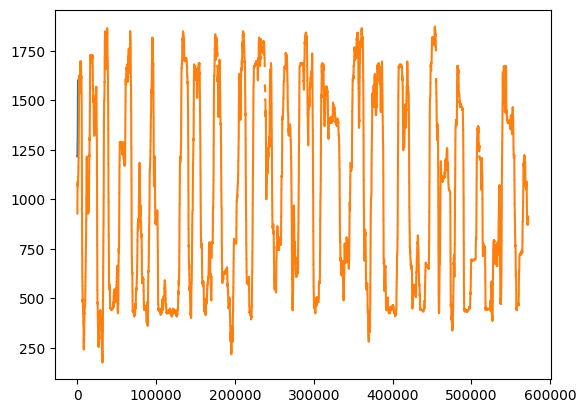

In [236]:
NFC = bouts['23_24_31_32']
NFC_sleap      = sleap['23_24_31_32']
rec_bounds = parse_ins_outs(ins_outs['23_24_31_32'], 'NFC')

for rec, subjects in NFC_sleap.items():
    print(rec)
    timestamps = timestamps_dict[rec.replace(".csv", "")]
    bounds        = rec_bounds[rec]

    for subject, sleap_array in subjects.items():
        key = f'{subject.replace(".","")}_NFC_merged.rec'
        first_timestamp = first_timestamp_dict[key.replace('_merged.rec', '')] #20kHz
        first_timestamp_ms = first_timestamp / 20 #ms
        timestamps_ms = (timestamps*1000) - first_timestamp_ms 
        if key not in sleap_dict:
            sleap_dict[key] = {}

        for epoch, (in_s, out_s) in bounds.items():
            info = sleap_to_1ms(sleap_array, timestamps_ms,
                                 start_ms=in_s, stop_ms=out_s)

            if not np.all(np.isnan(info['locations_1ms'])):
                print(f"  saving {subject} {epoch} from {rec}")
                if epoch == 'familiar' and subject == '3.2':
                    plt.plot(info['locations_1ms'][:, 0, 0])
                # merge — each epoch should only appear once per subject
                # if somehow it appears twice, warn rather than silently overwrite
                if epoch in sleap_dict[key]:                                                                                                                                                                                                                                                                                          
                    existing_valid = (~np.all(np.isnan(sleap_dict[key][epoch]['locations_1ms']),
                                                axis=(1, 2))).sum()
                    new_valid      = (~np.all(np.isnan(info['locations_1ms']),
                                                axis=(1, 2))).sum()
                    if new_valid > existing_valid:
                        print(f"  INFO: {key} {epoch} — overwriting: {new_valid} > {existing_valid} valid frames")
                        sleap_dict[key][epoch] = info
                    else:
                        print(f"  INFO: {key} {epoch} — keeping existing: {existing_valid} >= {new_valid} valid frames")
                else:
                    sleap_dict[key][epoch] = info

# sanity check
for key, epochs in sleap_dict.items():
    print(key, list(epochs.keys()))





In [237]:
epoch_pairs = { "NFC": {                                                                                                                                                                                                                                                        
      '23_24_31_32.1': [('2.3', '3.2'), ('2.3', '3.1'), ('2.3', '2.4')],     #NFC                                                                                                                                                                                             
      '23_24_31_32.2': [('2.4', '3.1'), ('2.4', '3.2'), ('3.1', '3.2')],
},
"FCN":{                                                                                                                                                                                                  
      '21_22_41_44.1': [('2.1', '4.1'), ('2.1', '2.2'), ('4.1', '2.2')],     #FCN                                                                                                                                                                                             
      '21_22_41_44.2': [('2.2', '4.4'), ('4.1', '4.4'), ('4.4', '2.1')], 
},
"NCF": {                                                                                                                                                                                                 
      '11_13_21_22.1': [('1.3', '2.1'), ('1.1', '1.3'), ('1.1', '2.1')],     #NCF                                                                                                                                                                                             
      '11_13_21_22.2': [('1.1', '2.2'), ('2.1', '2.2'), ('1.3', '2.2')], 
}, 
"CNF": {                                                                                                                                                                                                 
      '11_12_23_24.1': [('1.1', '1.2'), ('1.1', '2.4'), ('2.3', '1.1')],     #CNF                                                                                                                                                                                             
      '11_12_23_24.2': [('2.3', '2.4'), ('1.2', '2.3'), ('1.2', '2.4')],                                                                                                                                                                                                  
  } 
} 

In [238]:
import behavior.behavioral_epoch_tools as bet
LETTER_TO_EPOCH = {'C': 'cagemate', 'N': 'novel', 'F': 'familiar'}

behavior_dicts = {}

def slice_by_ms(arr, start_ms=None, stop_ms=None):
    """
    Slice a bout array where col 1 is timestamps in ms.

    Parameters
    ----------
    arr      : (n, 2+) numpy array where col 1 is timestamps in ms
    start_ms : start cutoff in ms (None = from beginning)
    stop_ms  : stop cutoff in ms  (None = to end)

    Returns
    -------
    filtered array
    """
    mask = np.ones(len(arr), dtype=bool)
    if start_ms is not None:
        mask &= arr[:, 1] >= start_ms
    if stop_ms is not None:
        mask &= arr[:, 1] < stop_ms
    return arr[mask]

for order_str, recs in epoch_pairs.items():
    common = list(recs.keys())[0].rsplit('.', 1)[0]  # e.g. '11_12_23_24'
    bouts_common = bouts[common]
    rec_bounds   = parse_ins_outs(ins_outs[common], order=order_str)

    for rec, pairs_list in recs.items():
        bounds = rec_bounds[f'{rec}.csv']   # ← per-rec bounds
        min_in_ms = min(in_s for in_s, _ in bounds.values())
        
        for epoch_idx, (s1, s2) in enumerate(pairs_list):
            epoch     = LETTER_TO_EPOCH[order_str[epoch_idx]]
            in_ms     = bounds[epoch][0] 
            out_ms    = bounds[epoch][1] if bounds[epoch][1] is not None else None

            arr1 = slice_by_ms(bouts_common[s1], start_ms=in_ms, stop_ms=out_ms)
            arr2 = slice_by_ms(bouts_common[s2], start_ms=in_ms, stop_ms=out_ms)

            key1 = f'{s1.replace(".", "")}_{order_str}_merged.rec'
            key2 = f'{s2.replace(".", "")}_{order_str}_merged.rec'

            # initialize if not yet seen
            if key1 not in behavior_dicts:
                behavior_dicts[key1] = {}
            if key2 not in behavior_dicts:
                behavior_dicts[key2] = {}
            baseline1  = bet.random_event_generator(start=0, stop=min_in_ms, len_event = 2000, no_events = 12)
            baseline2  = bet.random_event_generator(start=0, stop=min_in_ms, len_event = 2000, no_events = 12)
            behavior_dicts[key1][epoch]                        = arr1
            behavior_dicts[key1][f'exposure_{epoch_idx + 1}'] = arr1  # same array, exposure label
            behavior_dicts[key1]['baseline']                   = baseline1

            behavior_dicts[key2][epoch]                        = arr2
            behavior_dicts[key2][f'exposure_{epoch_idx + 1}'] = arr2  # same array, exposure label
            behavior_dicts[key2]['baseline']                   = baseline2

# sanity check
for key, epochs in behavior_dicts.items():
    print(key)
    for epoch, arr in epochs.items():
        print(f"  {epoch}: {arr.shape}")

23_NFC_merged.rec
  novel: (41, 2)
  exposure_1: (41, 2)
  baseline: (12, 2)
  familiar: (40, 2)
  exposure_2: (40, 2)
  cagemate: (13, 2)
  exposure_3: (13, 2)
32_NFC_merged.rec
  novel: (29, 2)
  exposure_1: (29, 2)
  baseline: (12, 2)
  familiar: (18, 2)
  exposure_2: (18, 2)
  cagemate: (39, 2)
  exposure_3: (39, 2)
31_NFC_merged.rec
  familiar: (37, 2)
  exposure_2: (37, 2)
  baseline: (12, 2)
  novel: (41, 2)
  exposure_1: (41, 2)
  cagemate: (37, 2)
  exposure_3: (37, 2)
24_NFC_merged.rec
  cagemate: (9, 2)
  exposure_3: (9, 2)
  baseline: (12, 2)
  novel: (43, 2)
  exposure_1: (43, 2)
  familiar: (25, 2)
  exposure_2: (25, 2)
21_FCN_merged.rec
  familiar: (12, 2)
  exposure_1: (12, 2)
  baseline: (12, 2)
  cagemate: (15, 2)
  exposure_2: (15, 2)
  novel: (14, 2)
  exposure_3: (14, 2)
41_FCN_merged.rec
  familiar: (17, 2)
  exposure_1: (17, 2)
  baseline: (12, 2)
  novel: (10, 2)
  exposure_3: (10, 2)
  cagemate: (21, 2)
  exposure_2: (21, 2)
22_FCN_merged.rec
  cagemate: (3, 2)

In [239]:
behavior_dicts['23_CNF_merged.rec'].keys()

dict_keys(['familiar', 'exposure_3', 'baseline', 'cagemate', 'exposure_1', 'novel', 'exposure_2'])

In [240]:
for rec, agents in non_social_dict.items():
      behavior_dicts[rec].update(agents) 
behavior_dicts['23_CNF_merged.rec'].keys()

dict_keys(['familiar', 'exposure_3', 'baseline', 'cagemate', 'exposure_1', 'novel', 'exposure_2', 'non_social_familiar', 'non_social_cagemate', 'non_social_novel'])

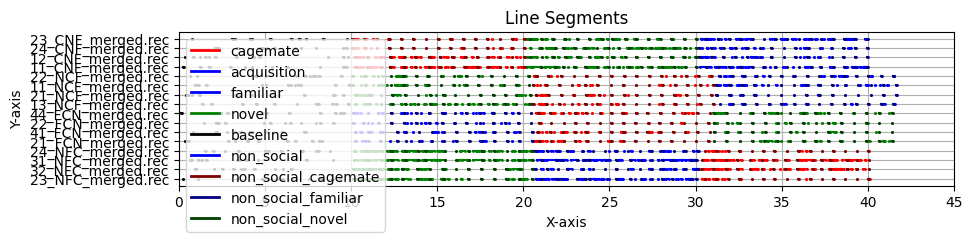

In [241]:
import matplotlib.colors as mcolors
                                                    
def darken(color, factor=0.5):
    rgb = mcolors.to_rgb(color)                                                                                                                                                                                                                                                                     
    return tuple(c * factor for c in rgb)
                                                                                                                                                                                                                                                                                                    
color_dict = {                                                                                                                                                                                                                                                                                    
    'cagemate':           'r',
    'acquisition':        'b',
    'familiar':           'b',
    'novel':              'g',
    'baseline':           'k',
    'non_social':         'b',
    'non_social_cagemate': darken('r'),
    'non_social_familiar': darken('b'),
    'non_social_novel':    darken('g'),
}

social_events = set(color_dict.keys())

recording_number = 0
plt.figure(figsize=(10, 2))
labels = []
for name, recording in behavior_dicts.items():
    labels.append(name)
    for event, snippets in recording.items():
        if event not in social_events:
            continue
        for i in range(len(snippets)):
            y = [recording_number, recording_number]
            x = snippets[i] / 1000 / 60
            plt.plot(x, y, marker='o', linestyle='-', c=color_dict[event], markersize=1)
    recording_number += .5

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.yticks(ticks=np.arange(len(labels)) / 2, labels=labels)
plt.title('Line Segments')
legend_labels = [plt.Line2D([0], [0], color=color_dict[label], lw=2, label=label) for label in color_dict]
plt.legend(handles=legend_labels)
plt.grid(True)
plt.xlim([0, 45])
plt.show()

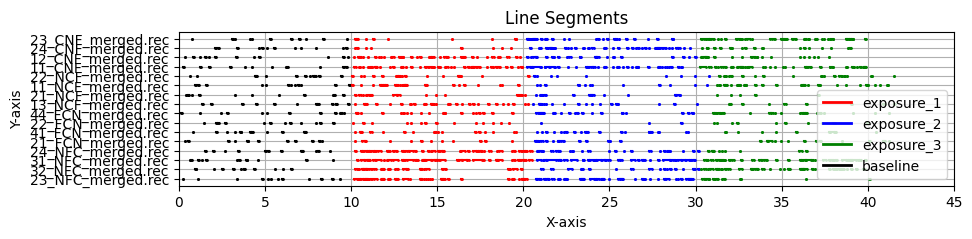

In [242]:
color_dict = {'exposure_1': 'r', 'exposure_2': 'b', 'exposure_3': 'g',
              'baseline' : 'k'}
recording_number = 0
plt.figure(figsize = (10,2))
labels = []
for name, recording in behavior_dicts.items():
    labels.append(name)
    for event, snippets in recording.items():
        if (event =='exposure_1'
            ) | (event == 'exposure_2'
                 ) | (event == 'exposure_3'
                    ) | (event == 'baseline'):
            for i in range(len(snippets)):
                y = [recording_number,recording_number]
                x = snippets[i]/1000/60
            # Plot the line segments
                plt.plot(x, y, marker='o', linestyle='-', c= color_dict[event], markersize = 1)
    recording_number += .5
# Optionally, you can add labels, title, etc.
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.yticks(ticks=np.arange(len(labels))/2, labels=labels)
plt.title('Line Segments')
legend_labels = [plt.Line2D([0], [0], color=color_dict[label], lw=2, label=label) for label in color_dict]
plt.legend(handles=legend_labels)
plt.grid(True)
plt.xlim([0,45])
plt.show()

In [243]:
pickle_this(behavior_dicts, 'pilot2/only_subjects/behavior_dict_by_frames.pkl')


In [250]:
subject_dict = {}
for rec, agents in behavior_dicts.items():
    subject = str(int(rec.split('_')[0])/10)  # e.g. '11'
    subject_dict[rec] = subject
print(subject_dict)

{'23_NFC_merged.rec': '2.3', '32_NFC_merged.rec': '3.2', '31_NFC_merged.rec': '3.1', '24_NFC_merged.rec': '2.4', '21_FCN_merged.rec': '2.1', '41_FCN_merged.rec': '4.1', '22_FCN_merged.rec': '2.2', '44_FCN_merged.rec': '4.4', '13_NCF_merged.rec': '1.3', '21_NCF_merged.rec': '2.1', '11_NCF_merged.rec': '1.1', '22_NCF_merged.rec': '2.2', '11_CNF_merged.rec': '1.1', '12_CNF_merged.rec': '1.2', '24_CNF_merged.rec': '2.4', '23_CNF_merged.rec': '2.3'}


In [252]:
import spike.spike_analysis.spike_collection as spike

#only_subject_collection = spike.SpikeCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\only_subjects_spike_collection\spike_collection.json")
#spike.SpikeCollection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Only_Subjects (phase 5)\sorted", subject_dict = subject_dict)

loading  11_CNF_merged.rec
loading  11_NCF_merged.rec
loading  12_CNF_merged.rec
loading  13_NCF_merged.rec
loading  21_FCN_merged.rec
loading  21_NCF_merged.rec
loading  22_FCN_merged.rec
loading  22_NCF_merged.rec
loading  23_CNF_merged.rec
loading  23_NFC_merged.rec
loading  24_CNF_merged.rec
loading  24_NFC_merged.rec
loading  31_NFC_merged.rec
31_NFC_merged.rec has no good units
and will not be included in the collection
loading  32_NFC_merged.rec
loading  41_FCN_merged.rec
loading  44_FCN_merged.rec
Please assign event dictionaries to each recording
as recording.event_dict
event_dict = {event name(str): np.array[[start(ms), stop(ms)]...]


In [253]:
for recording in only_subject_collection.recordings:
    recording.set_event_dict(behavior_dicts[recording.name])

In [254]:
only_subject_collection.save_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\only_subjects_spike_collection\spike_collection.json", notes = 'updated with more accurate behavior dicts including missing 3.2 familiar epoch')

In [ ]:


#NFC
#23_24_31_32.1 = 23_32, 23_31, 23_24
#23_24_31_32.2 = 24_31, 24_32, 31_32

#FCN
#21_22_41_44.1 = 21_41, 21_22, 41_22 
#21_22_41_44.2 = 22_44, 41_44, 44_21

#NCF
#11_13_21_22.1 = 13_21, 11_13, 11_21
#11_13_21_22.2 = 11_22, 21_22, 13_22

#CNF
# 11_12_23_24.1 = 11_12, 11_24, 23_11
# 11_12_23_24.2 = 23_24, 12_23, 12_24

In [ ]:
order_key = {'C': 'cagemate', 'F': 'familiar', 'N': 'novel'}

paired_sleap_dict = {}

for recording, recording_sleap_info in sleap_dict.items():
    subject = str(int(recording.split('_')[0]) / 10)
    order   = recording.split('_')[1]
    recs    = epoch_pairs[order]

    paired_sleap_dict[recording] = {}

    for i, agent_letter in enumerate(order):
        epoch = order_key[agent_letter]

        if epoch not in recording_sleap_info:
            continue

        # find partner for this epoch
        partner = None
        for rec_pairs in recs.values():
            pair = rec_pairs[i]
            if subject in pair:
                partner = next(s for s in pair if s != subject)
                break

        if partner is None:
            print(f"no partner found for {subject} {epoch}")
            continue

        partner_key = f"{partner.replace('.','')}_{ order}_merged.rec"

        if partner_key not in sleap_dict or epoch not in sleap_dict[partner_key]:
            print(f"partner {partner_key} missing {epoch}")
            continue

        s_locs = recording_sleap_info[epoch]['locations_1ms']   # (T, nodes, axes)
        p_locs = sleap_dict[partner_key][epoch]['locations_1ms'] # (T, nodes, axes)

        paired_sleap_dict[recording][epoch] = {
            'locations_1ms' : np.stack([s_locs, p_locs], axis=-1),  # (T, nodes, axes, 2)
            'time_ms'       : recording_sleap_info[epoch]['time_ms'],
            'subject'       : subject,
            'partner'       : partner,
        }

# sanity check
for rec, epochs in paired_sleap_dict.items():
    for epoch, info in epochs.items():
        print(f"{rec} | {epoch}: {info['locations_1ms'].shape} "
              f"({info['subject']} + {info['partner']})")


    
    

11_CNF_merged.rec | cagemate: (597592, 9, 2, 2) (1.1 + 1.2)
11_CNF_merged.rec | novel: (593015, 9, 2, 2) (1.1 + 2.4)
11_CNF_merged.rec | familiar: (589828, 9, 2, 2) (1.1 + 2.3)
12_CNF_merged.rec | cagemate: (597592, 9, 2, 2) (1.2 + 1.1)
12_CNF_merged.rec | novel: (591144, 9, 2, 2) (1.2 + 2.3)
12_CNF_merged.rec | familiar: (589204, 9, 2, 2) (1.2 + 2.4)
23_CNF_merged.rec | cagemate: (603063, 9, 2, 2) (2.3 + 2.4)
23_CNF_merged.rec | novel: (591144, 9, 2, 2) (2.3 + 1.2)
23_CNF_merged.rec | familiar: (589828, 9, 2, 2) (2.3 + 1.1)
24_CNF_merged.rec | cagemate: (603063, 9, 2, 2) (2.4 + 2.3)
24_CNF_merged.rec | novel: (593015, 9, 2, 2) (2.4 + 1.1)
24_CNF_merged.rec | familiar: (589204, 9, 2, 2) (2.4 + 1.2)
11_NCF_merged.rec | novel: (620040, 9, 2, 2) (1.1 + 2.2)
11_NCF_merged.rec | cagemate: (634799, 9, 2, 2) (1.1 + 1.3)
11_NCF_merged.rec | familiar: (633344, 9, 2, 2) (1.1 + 2.1)
13_NCF_merged.rec | novel: (617891, 9, 2, 2) (1.3 + 2.1)
13_NCF_merged.rec | cagemate: (634799, 9, 2, 2) (1.3 + 1.1

In [ ]:
feature_legend = [
    'distance',
    'velocity_mouse1', 'velocity_mouse2',
    'moving_angle_mouse1', 'moving_angle_mouse2',
    'front_orientation_mouse1', 'front_orientation_mouse2',
    'rump_orientation_mouse1', 'rump_orientation_mouse2',
    'body_angle_mouse1', 'body_angle_mouse2']
node_dict = list(sleap_objs.values())[0].node_dict
for rec, sleap_info in paired_sleap_dict.items():
    for agent, agent_info in sleap_info.items():
        pos = agent_info['locations_1ms']
        pos = smooth_locations(fill_missing(pos))
        velocities = node_velocity(pos, node_dict['Center']).T #frames, mice_velocites
        distances = distances_between_mice(pos, node_dict['Center']).reshape(-1, 1)
        front_orientations = orientation(pos, node_dict['Nose'],
                                        node_dict['Head'],
                                        node_dict['Neck']).T #frames, orientations
        body_angle = node_angles(pos, node_dict['Head'],
                                    node_dict['Center'],
                                    node_dict['Tail_Base']).T # frames, angles
        rump_orientation = orientation(pos, node_dict['Nose'],
                                        node_dict['Head'],
                                        node_dict['Tail_Base']).T
        moving_angles = compute_moving_angle(pos, node_dict['Center']).T #frames, moving angles

        feature_matrix = np.hstack([distances, velocities, moving_angles, front_orientations, rump_orientation, body_angle])
        agent_info['features_1ms'] = feature_matrix
        agent_info['feature_legend'] = feature_legend
        agent_info['locations_1ms'] = pos
        agent_info['node_dict'] = node_dict

In [ ]:
pickle_this(sleap_dict, 'pilot2/only_subjects/sleap_dicts.pkl')

In [ ]:
import pandas as pd
import numpy as np
import re

def _recording_to_subject(rec_name):
    # "11_CNF_merged.rec" → "1.1"
    num = rec_name.split('_')[0]
    return f"{num[0]}.{num[1:]}"

def _get_exposure_map(rec_name):
    # "11_CNF_merged.rec" → {'cagemate': 1, 'novel': 2, 'familiar': 3}
    letter_to_agent = {'C': 'cagemate', 'N': 'novel', 'F': 'familiar'}
    letters = re.search(r'_([CNF]+)_', rec_name).group(1)
    return {letter_to_agent[l]: i + 1 for i, l in enumerate(letters)}

rows = []

for rec, agents in behavior_dicts.items():
    subject      = _recording_to_subject(rec)
    exposure_map = _get_exposure_map(rec)

    for agent, trials in agents.items():
        try:
            sleap_info     = paired_sleap_dict[rec][agent]
            feature_mat    = sleap_info['features_1ms']    # [frames, n_features]
            time_ms        = sleap_info['time_ms']          # [frames,] actual timestamp per frame
            feature_legend = sleap_info['feature_legend']
            partner        = sleap_info.get('partner', None)
            exposure       = exposure_map[agent]

            for trial_idx, (start_ms, stop_ms) in enumerate(trials):
                start_ms = int(start_ms)
                stop_ms  = int(stop_ms)

                mask = (time_ms >= start_ms) & (time_ms < stop_ms)
                if not mask.any():
                    continue

                avg_features = np.nanmean(feature_mat[mask, :], axis=0)

                row = {
                    'subject':   subject,
                    'recording': rec,
                    'agent':     agent,
                    'partner':   partner,
                    'trial':     trial_idx,
                    'exposure':  exposure,
                    'event_length': stop_ms - start_ms
                }
                for feat_name, feat_val in zip(feature_legend, avg_features):
                    row[feat_name] = feat_val

                rows.append(row)
        except KeyError:
            pass

sleap_behavior_df = pd.DataFrame(rows)
sleap_behavior_df

,subject,recording,agent,partner,trial,exposure,event_length,distance,velocity_mouse1,velocity_mouse2,moving_angle_mouse1,moving_angle_mouse2,front_orientation_mouse1,front_orientation_mouse2,rump_orientation_mouse1,rump_orientation_mouse2,body_angle_mouse1,body_angle_mouse2
0,2.3,23_NFC_merged.rec,novel,3.2,0,1,9978,431.701340,0.120357,0.118977,9.044678,-5.864569,0.519222,1.678954,0.585083,2.498046,3.191687,1.657653
1,2.3,23_NFC_merged.rec,novel,3.2,1,1,2010,257.196585,0.299902,0.253294,1.374700,-2.935023,1.618142,2.320746,0.687291,1.675650,1.761724,0.016284
2,2.3,23_NFC_merged.rec,novel,3.2,2,1,3049,316.406091,0.317216,0.580471,-9.655024,9.183773,1.673550,2.700653,1.227645,2.220513,0.942931,0.568246
3,2.3,23_NFC_merged.rec,novel,3.2,3,1,6999,344.563828,0.149628,0.103475,-10.269891,1.617449,1.881502,0.845160,3.677319,0.649974,1.991369,2.377755
4,2.3,23_NFC_merged.rec,novel,3.2,4,1,970,268.235734,0.546504,0.162638,-38.120167,1.318554,3.089591,1.307422,2.793402,1.243996,2.482174,3.006899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116,2.3,23_CNF_merged.rec,novel,1.2,22,2,554,238.250714,0.159840,0.299111,-10.442485,17.267959,3.047660,2.145300,3.469290,1.568868,0.000000,3.119182
1117,2.3,23_CNF_merged.rec,novel,1.2,23,2,554,271.279276,0.495140,0.041056,8.405286,8.773788,1.243815,0.760771,0.596995,0.053744,1.723003,3.136202
1118,2.3,23_CNF_merged.rec,novel,1.2,24,2,4850,292.474962,0.177469,0.121109,-0.402415,-8.866187,0.550421,3.611890,0.864882,3.631243,2.434375,3.437072
1119,2.3,23_CNF_merged.rec,novel,1.2,25,2,2009,408.157935,0.131198,0.051404,-3.972690,-1.844152,0.345251,1.973148,0.818121,4.111999,3.018743,3.916369


In [ ]:
sleap_behavior_df.to_csv('pilot2/only_subjects/sleap_behavior.csv')

In [ ]:
pickle_this(paired_sleap_dict, 'pilot2/only_subjects/paired_sleap_dicts.pkl')